## What Seattle Read During Covid: A Longitudinal Analysis (2018-2025) of Seattle Public Library Borrowing Patterns During the Covid-19 Pandemic

### Introduction

Every day, residents of a city make countless choices about what to read, watch, learn, and explore. Taken individually, these decisions reflect personal interests, needs, and curiosities. Taken in aggregate, they may offer a unique window into how communities respond to periods of stability, disruption, and recovery.

Public libraries occupy a distinctive role in civic life, providing access to information, entertainment, education, and cultural resources across changing social and economic conditions. Drawing on Seattle Public Library circulation data from 2018 through 2025, this project examines how borrowing behavior changed before, during, and after the COVID-19 pandemic. By analyzing trends in material formats, subject areas, and selected themes, the study explores whether library circulation data can reveal shifts in how people sought information, entertainment, and community during a period of significant uncertainty.

The COVID-19 pandemic disrupted daily life in ways that affected how people worked, learned, socialized, and accessed public services. Libraries were no exception. As physical access became constrained and digital services expanded, borrowing behavior may have changed in both expected and unexpected ways. This project asks a simple question:

**What can Seattle Public Library borrowing patterns tell us about how a community responded to the COVID-19 pandemic?**

Rather than attempting to measure individual behavior, the analysis focuses on aggregate circulation trends across four periods:

- Pre-Covid (2018-2019)
- Covid (2020-2021)
- Recovery (2022-2023)
- Post-Covid (2024-2025)

Comparing these periods provides an opportunity to examine whether readers changed what they borrowed, how they borrowed it, or both.

### Other Resources

Other articles written on this subject are listed below for further reading:
- [Seattle Public Library’s Open Checkout Data: What Can It Tell Us About Readers and Book Popularity More Broadly?](https://storage.googleapis.com/jnl-up-j-johd-files/journals/1/articles/332/689c81f8cc758.pdf)
    - [GitHub repo](https://github.com/neelgupta2112/Seattle-Public-Library-Library-Checkout-Data)
- [Where Is All the Book Data?](https://www.publicbooks.org/where-is-all-the-book-data/)
- [The Canon in Circulation: Tracking the Reception of Norton Anthology Authors in Library Checkout Data](https://anthology.ach.org/volumes/vol0003/the-canon-in-circulation-tracking-reception-of-in/10.63744@P6qPH135jhY2.pdf)

### Dataset Description
The data in question is made available freely via the Seattle Open Data portal: [Checkouts by Title | City of Seattle Open Data portal](https://data.seattle.gov/Community-and-Culture/Checkouts-by-Title/tmmm-ytt6/about_data). The dataset in question contains 51.3 million records as of July 2026. Each row is a checkout count and contains identifiers about each book, including ISBN/title, year, month, and sum of checkouts by month. It also contains other descriptive metadata, such as genre, medium (e.g., physical/digital), type of resource, publisher, and creator. 

### Research Questions
This analysis seeks to answer the following questions:

- ow did borrowing formats change before, during, and after the Covid-19 pandemic?
- Did patrons change the types of materials they borrowed, or primarily the formats through which they accessed them?
- Which subject combinations remained stable across all four periods, and which experienced meaningful changes?
- How did circulation of selected themes, including LGBTQIA+ and African American-related materials, change over time?
- What do these borrowing patterns suggest about how Seattle residents used library resources during a period of significant societal disruption?

In [1]:
import os
import requests
from dotenv import load_dotenv #to store API key
from pathlib import Path
import pandas as pd
import pyarrow #parquet conversion engine
import duckdb #to run sql queries against parquet files directly
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns
import textwrap


In [3]:
load_dotenv() #recommend adding .env to .gitignore if doesn't already exist

api_key = os.getenv("SOCRATA_API_KEY") #storing api key in .env to avoid hard-coding

#test request to make sure it runs
response=requests.get(
    "https://data.seattle.gov/resource/tmmm-ytt6.json"
    #,headers={"X-App-Token": api_key}
    ,params={"$limit": 50000}
)

print(response.status_code) #looking for 200 - if you get 403 try commenting out the header in the request and rerun

200


### Bronze Layer

Because the data is so large, it took me a few tries to figure out the best way to work with it. I first tried to make use of Socrata's server-side aggregations to pre-filter . This approach was fine if I planed to export via CSV. However, I eventually found that querying what was essentially a SQL view via the API still made the call time out, so I eventually abandoned that method. Maybe others will have better luck than I did.(**Note**: Socrata's Soda3 API endpoint has a default cap of 1000 rows, so I manually set the row limits via this method: [Exceed 1k limit cap](https://support.socrata.com/hc/en-us/articles/202949268-How-to-query-more-than-1000-rows-of-a-dataset) Soda3 also requires authentication via API key so I created that as a pre-step: [SODA3 developer docs](https://support.socrata.com/hc/en-us/articles/34730618169623-Introducing-the-new-SODA3-API) and [API Key Creation](https://support.socrata.com/hc/en-us/articles/210138558-Generating-App-Tokens-and-API-Keys)* )


The second attempt was to export the data directly (no server-side aggregation) and compress it into Parquet files - no transformation. For this project, Parquet beats CSVs for a couple reasons, namely data compression and performance. More info here: [Apache Parquet Explained](https://www.datacamp.com/tutorial/apache-parquet) I also add caching locally so that any downstream analyses use the cached versions of the data if they exist, minimizing the risk of hitting API rate limits.(**Note:** It seems like maybe my API key wasn't needed after all, maybe the documentation is out of date. Oh well.)

In [2]:
def data_download(base_url, checkoutyear, limit=100000): #chunk the download
    
    cache_dir_bronze = Path("cache/bronze") #create cache files in cwd
    cache_dir_silver = Path("cache/silver") #create placeholder for clean files 
    cache_dir_gold = Path("cache/gold") #create placeholder for analytical files 
   
    cache_dir_bronze.mkdir(exist_ok=True) #don't recreate it if it already exists 
    cache_dir_silver.mkdir(exist_ok=True) #don't recreate it if it already exists 
    cache_dir_gold.mkdir(exist_ok=True) #don't recreate it if it already exists 

    offset=0 #for pagination
    total_rows=0 #to make sure row count matches
    parquet_file_count=0 #to check how many parquet files were written to disk
    
    while True:
        chunk_file=(cache_dir_bronze / f"spl_checkouts_{checkoutyear}_{offset}.parquet") #create parquet for chunk
        
        if chunk_file.exists(): #if notebook crashes, this will pick up download where it left off
            print(f"Skipping offset {offset:,} "f"because {chunk_file.name} already exists.")
            offset += limit
            continue
            
        params = {
            "$where": f"checkoutyear = {checkoutyear}"
            ,"$limit": limit #to limit memory taxing
            ,"$offset": offset #paginate
            ,"$order": "usageclass, checkouttype, materialtype, checkoutyear, checkoutmonth, checkouts, title, isbn, creator, subjects, publisher, publicationyear"
            #dataset doesn't contain PK so by ordering by all fields, it's ensuring the data download is in the same order each time - prevents duplicate rows in the offset
            #definitely a hacky way of preventing dupes, but it works
            #may contemplate later making a compound PK from all fields and then deleting dupes once I get to silver, as an extra check
        }

        response = requests.get(
        base_url,
        params=params
            )
        
        response.raise_for_status()

        data = response.json()
        
        if not data:
            break #if no data, end the loop
        
        chunk=pd.DataFrame(data)  #convert to dataframe
        chunk.to_parquet(chunk_file, index=False) #export to parquet
        total_rows += len(chunk) #add to total rowcount
        parquet_file_count += 1 #add to total parquet file count
        print(f"Downloaded offset {offset:,}, {chunk_file.name}.")

        del chunk #delete chunk once saved - keeps memory flat

        offset += limit #next set of rows
        
    return {"year": checkoutyear, "rows": total_rows,"files": parquet_file_count}

Obviously if this is run later in 2026 the result will be higher than what it is today (7/30/26). I can crosscheck it on the [portal](https://data.seattle.gov/Community-and-Culture/Checkouts-by-Title/tmmm-ytt6/explore/query/SELECT%0A%20%20%60usageclass%60%2C%0A%20%20%60checkouttype%60%2C%0A%20%20%60materialtype%60%2C%0A%20%20%60checkoutyear%60%2C%0A%20%20%60checkoutmonth%60%2C%0A%20%20%60checkouts%60%2C%0A%20%20%60title%60%2C%0A%20%20%60isbn%60%2C%0A%20%20%60creator%60%2C%0A%20%20%60subjects%60%2C%0A%20%20%60publisher%60%2C%0A%20%20%60publicationyear%60%0AWHERE%20%60checkoutyear%60%20%3D%202026/page/filter):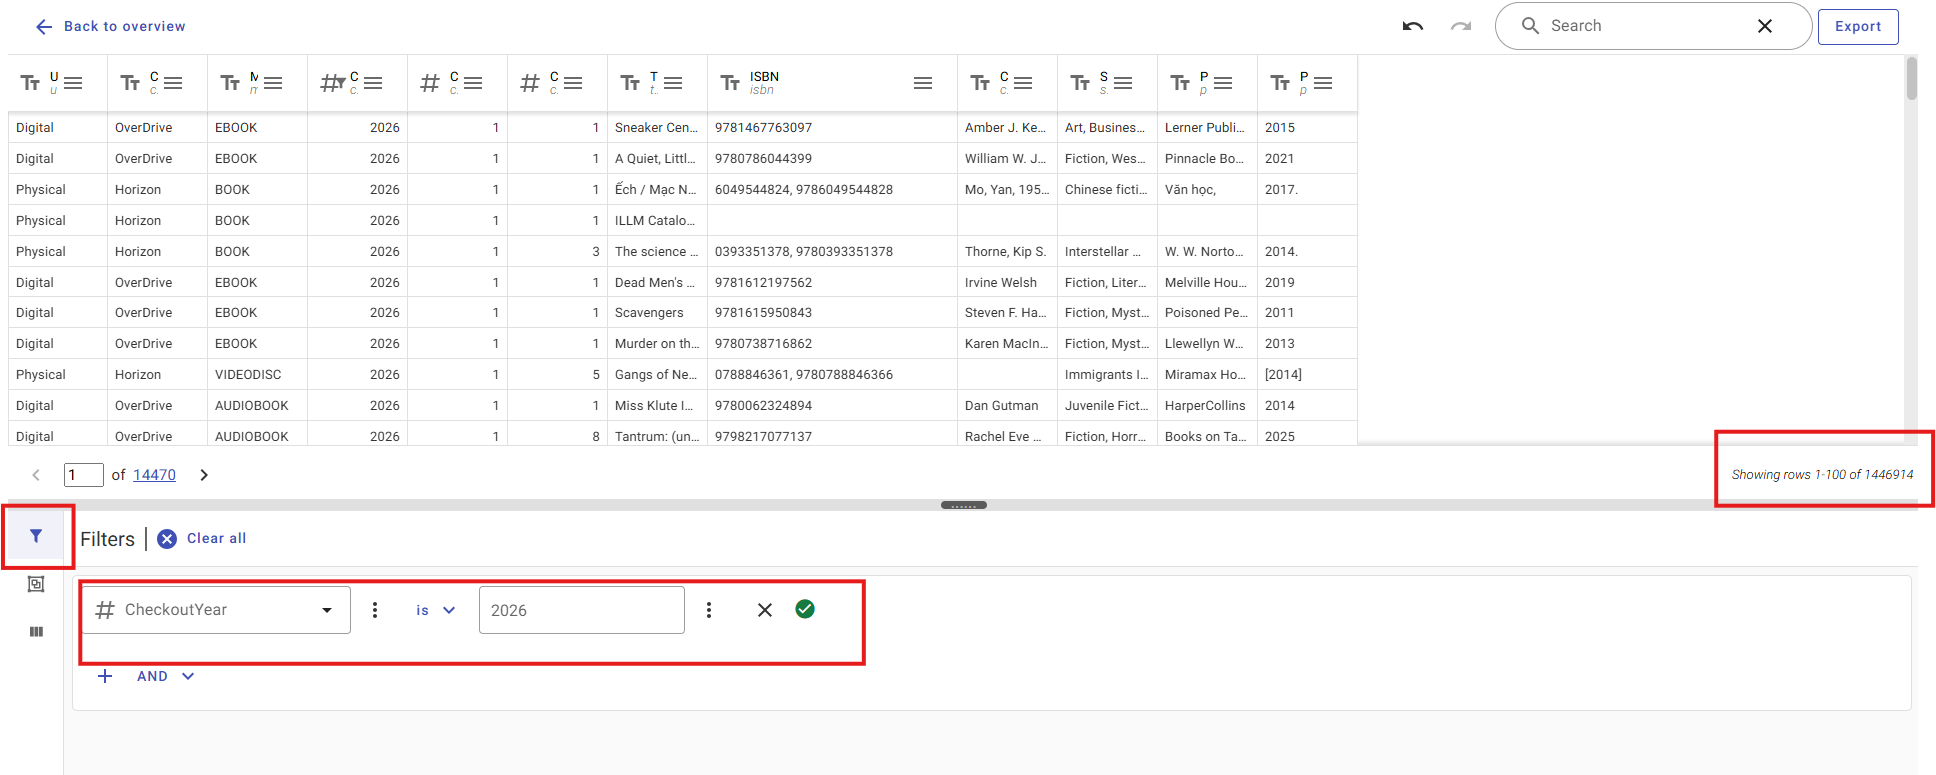


In [5]:
base_url = "https://data.seattle.gov/resource/tmmm-ytt6.json" #base url for API call

result = data_download(base_url, checkoutyear=2026)


Skipping offset 0 because spl_checkouts_2026_0.parquet already exists.
Skipping offset 100,000 because spl_checkouts_2026_100000.parquet already exists.
Skipping offset 200,000 because spl_checkouts_2026_200000.parquet already exists.
Skipping offset 300,000 because spl_checkouts_2026_300000.parquet already exists.
Skipping offset 400,000 because spl_checkouts_2026_400000.parquet already exists.
Skipping offset 500,000 because spl_checkouts_2026_500000.parquet already exists.
Skipping offset 600,000 because spl_checkouts_2026_600000.parquet already exists.
Skipping offset 700,000 because spl_checkouts_2026_700000.parquet already exists.
Skipping offset 800,000 because spl_checkouts_2026_800000.parquet already exists.
Skipping offset 900,000 because spl_checkouts_2026_900000.parquet already exists.
Skipping offset 1,000,000 because spl_checkouts_2026_1000000.parquet already exists.
Skipping offset 1,100,000 because spl_checkouts_2026_1100000.parquet already exists.
Skipping offset 1,200

Now that the data is saved and compressed, I'm going to use [DuckDB](https://duckdb.org/install/?platform=windows&environment=python) to write SQL queries directly against all the parquet files at once.

In [6]:
#test query - should return ~1.69MM rows
duckdb.sql("""
    SELECT count(*)
    FROM 'cache/bronze/spl_checkouts_2026_*.parquet' 
""").df()

,count_star()
0,1695606


### Silver Layer

It worked! Now I can write queries directly against the data. Before that though, I checked datatypes. Sure enough, Socrata brought in all the data as text strings. So I'll need to recast some fields for performance reasons first. If I was doing a one-off analysis, I could recast via a [temp table](https://www.geeksforgeeks.org/sql/what-is-temporary-table-in-sql/) or a [CTE (common table expression)](https://www.geeksforgeeks.org/sql/cte-in-sql/), and then query that, but since I plan to use this data for a while, it's worth the trouble to leave these files as my bronze layer and create a silver layer for all my cleaned vals.

In [5]:
#making this into a function so it chunks all parquets by year and cleans them

def silver_layer(checkoutyear):
    
    #make the silver file
    silver_file=(f"cache/silver/checkouts_clean_{checkoutyear}.parquet")
    
    #skip if already exists
    if Path(silver_file).exists():
        print(f"Silver layer already exists for {checkoutyear}")
        return
    
    #identify bronze files to transform    
    bronze_pattern = (f"cache/bronze/spl_checkouts_{checkoutyear}_*.parquet")
    
    #if checkoutyear<= 2021, ISBN doesn't exist, so I need to create a dummy val for the yrs we don't have it. 
    #retrieve schema
    schema = duckdb.sql(f"""
    DESCRIBE
    SELECT *
    FROM read_parquet(
    '{bronze_pattern}',
    union_by_name = true
    )
    """).df()
   
    #check if ISBN exists
    has_isbn = "isbn" in schema["column_name"].str.lower().tolist()
    
    #create an isbm expression to insert into SQL query
    if has_isbn:
        isbn_expression = "COALESCE(isbn, "") as isbn"
    else:
        isbn_expression = "'' as isbn"
    
    #create the silver layer
    duckdb.sql(f"""COPY (
        SELECT
            usageclass,
            checkouttype,
            materialtype,
            TRY_CAST(checkoutyear AS INTEGER) AS checkoutyear,
            TRY_CAST(checkoutmonth AS INTEGER) AS checkoutmonth,
            TRY_CAST(checkouts AS INTEGER) AS checkouts,
            title,
            {isbn_expression},
            creator,
            subjects,
            publisher,
            publicationyear
        FROM read_parquet('{bronze_pattern}', union_by_name = true)
    )
    TO '{silver_file}'
    (FORMAT PARQUET)""")
    
    #print confirmation
    print(f"Created {silver_file}")

#create silver layer for 2026
silver_layer(2026)

### Gold Layer

The next thing I need to do is create the Gold (analytical) layer, aka the tables from which I'll primarily be working to do my modeling etc. The views that I think will be helpful initially are 1) Material Type trends, and 2) Subject/Genre trends. I'm going to make those into parquet files. In the ```data_download``` function I took the liberty of creating space for each tier of data, so an empty Gold cache already exists. I should be able to query the data from Silver, transform it, and dump it into Gold. Probably worth mentioning here that the data is reported by the library monthly, so I'll want to include month as a field if I want to understand trends, at least at first.

In [4]:
#functions for creation of gold layer should parquet by analytical subject spanning years, not per year

#material trends
def build_material_trends(input_file): #just pulling from "cache/silver/checkouts_clean_2026.parquet" at first to test
    output_file = "cache/gold/material_trends_by_year_and_month.parquet"

    if Path(output_file).exists():
        print(f"{output_file} already exists")
        return


    duckdb.sql(f"""COPY (
        SELECT
           checkoutyear,
            checkoutmonth,
            materialtype,
           SUM(checkouts) AS sum_checkouts
        FROM read_parquet(
           '{input_file}',
           union_by_name = true
        )
       GROUP BY 1,2,3
    )
    TO'{output_file}'
    (FORMAT PARQUET)
    """)

    print(f"Created {output_file}")
    return

#build it
build_material_trends("cache/silver/checkouts_clean_2026.parquet")


cache/gold/material_trends_by_year_and_month.parquet already exists


In [3]:
#genre trends 
def build_subject_trends(input_file):
    output_file = "cache/gold/subject_trends_by_year_and_month.parquet"

    if Path(output_file).exists():
        print(f"{output_file} already exists")
        return


    duckdb.sql(f"""COPY
    (
    SELECT checkoutyear
    , checkoutmonth
    , subjects
    , sum(checkouts) as sum_checkouts
    FROM read_parquet(
           '{input_file}',
           union_by_name = true
        )
       GROUP BY 1,2,3
    )
    TO'{output_file}'
    (FORMAT PARQUET)
    """)

    print(f"Created {output_file}")
    return



### Initial Data Exploration - 2026

Before I scale up the data pull to multiple years, I want to run some basic analysis on 2026 data to understand what I'm looking at.

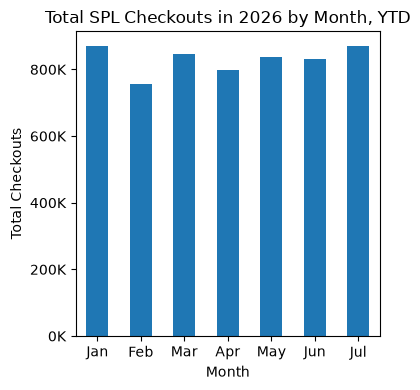

In [15]:
#total checkouts by month - can grab from any of my gold files since we're just summing

#sql query
mom_totals = duckdb.sql("""
SELECT checkoutyear
    ,checkoutmonth
    ,sum(sum_checkouts) as total_checkouts
FROM 'cache/gold/material_trends_by_year_and_month.parquet' 
WHERE checkoutyear = 2026
GROUP BY 1,2
ORDER BY 1,2
""").df()

#make months pretty instead of just integers
month_map = {
    1:"Jan", 2:"Feb", 3:"Mar", 4:"Apr",
    5:"May", 6:"Jun", 7:"Jul", 8:"Aug",
    9:"Sep", 10:"Oct", 11:"Nov", 12:"Dec"
}
#map across df
mom_totals["month_name"] = (
    mom_totals["checkoutmonth"]
    .map(month_map)
)

#plot it
ax=mom_totals.plot(
x="month_name",
y="total_checkouts",
kind="bar",
figsize=(4,4)
)

#formatting
ax.tick_params(axis="x",rotation=360,labelsize=10) #making labels pretty
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{x/1000:.0f}K')) #turns "200000" into "200k"
ax.get_legend().remove() #don't need this
plt.xlabel("Month")
plt.ylabel("Total Checkouts")
plt.title("Total SPL Checkouts in 2026 by Month, YTD")
plt.tight_layout()
plt.show()

In [26]:
#top 10 material trends MoM

#sql query to get top material types in 2026 in a CTE and then their behavior MoM

mom_material_totals = duckdb.sql("""

WITH top_materials as (
SELECT materialtype
, sum(sum_checkouts) as total_checkouts
FROM 'cache/gold/material_trends_by_year_and_month.parquet'
WHERE checkoutyear=2026
GROUP BY 1
ORDER BY 2 DESC
LIMIT 10
)


SELECT m.checkoutyear
    ,m.checkoutmonth
    ,m.materialtype
    ,sum(m.sum_checkouts) as total_checkouts
FROM 'cache/gold/material_trends_by_year_and_month.parquet' AS m
INNER JOIN top_materials as t
    ON m.materialtype = t.materialtype
GROUP BY 1,2,3
ORDER BY 1,2,3

""").df()

#mom_material_totals

,checkoutyear,checkoutmonth,materialtype,total_checkouts
0,2026,1,AUDIOBOOK,284770.0
1,2026,1,BOOK,236413.0
2,2026,1,EBOOK,279603.0
3,2026,1,"ER, SOUNDREC",710.0
4,2026,1,LARGEPRINT,842.0
...,...,...,...,...
65,2026,7,MIXED,4125.0
66,2026,7,MUSIC,318.0
67,2026,7,REGPRINT,13741.0
68,2026,7,SOUNDDISC,12584.0


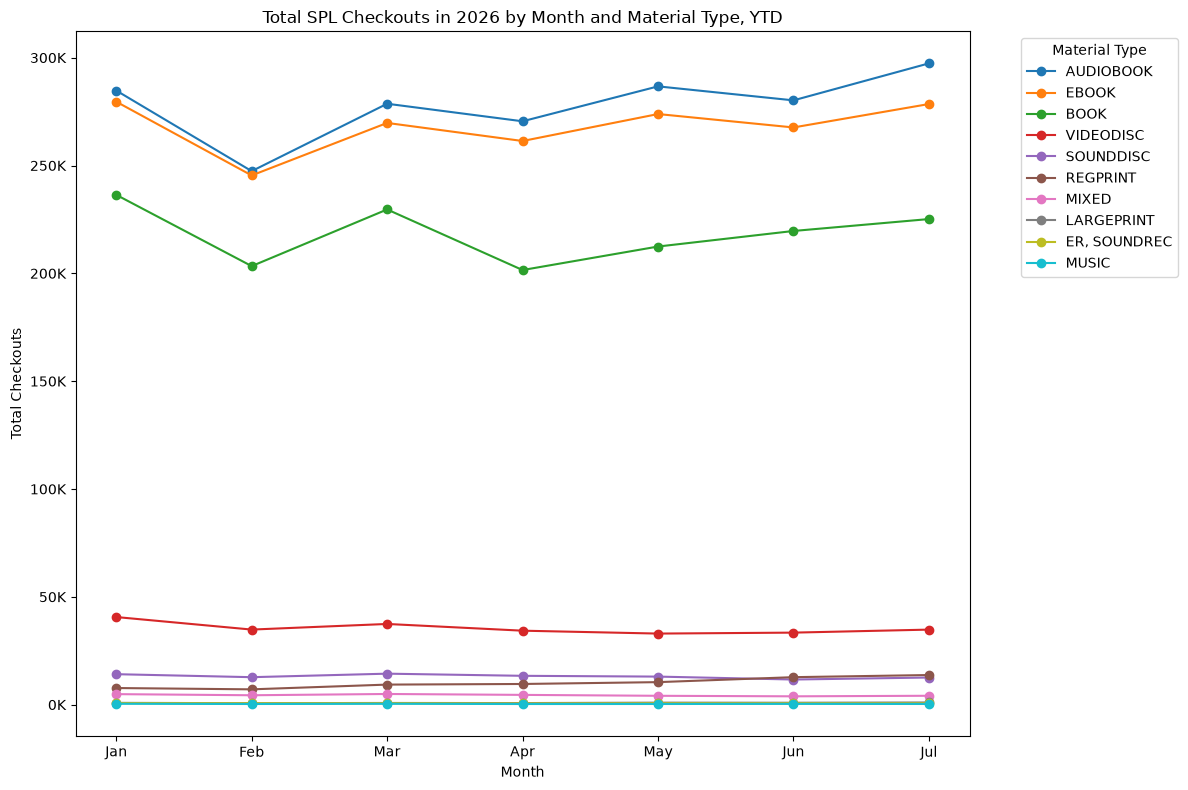

In [27]:
#making a multi-line plot to better represent totals - need to pivot data first

#order the df by desc order
materialtype_order=(mom_material_totals.groupby("materialtype")["total_checkouts"].sum().sort_values(ascending=False).index)

#pivot the data
mom_material_totals_pivoted = mom_material_totals.pivot_table(
    index="checkoutmonth",
    columns="materialtype",
    values="total_checkouts",
    aggfunc="sum")

#organize the data by material type order desc
mom_material_totals_pivoted=mom_material_totals_pivoted[materialtype_order]

#reuse month mapping map across df
mom_material_totals_pivoted.index = (
    mom_material_totals_pivoted.index
    .map(month_map)
)


#plot it
ax=mom_material_totals_pivoted.plot(
    kind="line",
    marker="o",
    figsize=(12,8))


#formatting
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{x/1000:.0f}K')) #turns "200000" into "200k"

plt.legend(title="Material Type", bbox_to_anchor=(1.05,1), loc="upper left") #need a legend for this, tuck it in the corner
plt.xlabel("Month")
plt.ylabel("Total Checkouts")
plt.title("Total SPL Checkouts in 2026 by Month and Material Type, YTD")
plt.tight_layout()
plt.show()

It's clear from the data that Audiobooks, Ebooks, and Books are the most checked out types by far. 

Next, let's look at the most checked out items.

In [28]:
#top 5 most checked out items - I tried top 10 and it got too messy

#sql query to get top items in 2026 in a CTE and then their behavior MoM

mom_title_totals = duckdb.sql("""

WITH top_titles as (
SELECT title
, sum(sum_checkouts) as total_checkouts
FROM 'cache/gold/title_trends_by_year_and_month.parquet'
WHERE checkoutyear=2026
GROUP BY 1
ORDER BY 2 DESC
LIMIT 5
)


SELECT m.checkoutyear
    ,m.checkoutmonth
    ,m.title
    ,sum(m.sum_checkouts) as total_checkouts
FROM 'cache/gold/title_trends_by_year_and_month.parquet' AS m
INNER JOIN top_titles as t
    ON m.title = t.title
GROUP BY 1,2,3
ORDER BY 1,2,3

""").df()

#mom_title_totals

,checkoutyear,checkoutmonth,title,total_checkouts
0,2026,1,FlexTech--Laptops.,1036.0
1,2026,1,Game Changer: (unabridged),1803.0
2,2026,1,Headphones / Seattle Public Library.,2843.0
3,2026,1,Heated Rivalry: (unabridged),2544.0
4,2026,1,Wuthering Heights: (unabridged),1127.0
5,2026,2,FlexTech--Laptops.,1063.0
6,2026,2,Game Changer: (unabridged),1161.0
7,2026,2,Headphones / Seattle Public Library.,2492.0
8,2026,2,Heated Rivalry: (unabridged),1708.0
9,2026,2,Wuthering Heights: (unabridged),1853.0


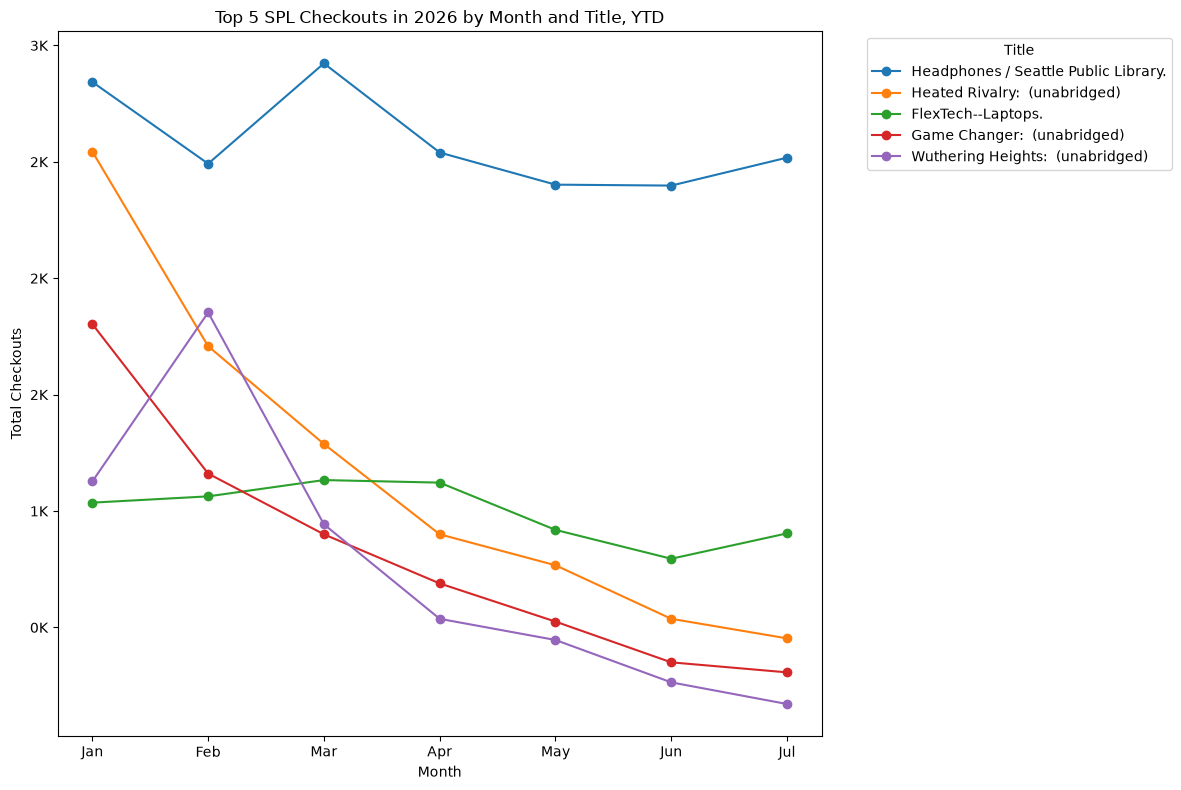

In [29]:
#making a multi-line plot to better represent totals - need to pivot data first

#order the df by desc order
title_order=(mom_title_totals.groupby("title")["total_checkouts"].sum().sort_values(ascending=False).index)

#pivot the data
mom_title_totals_pivoted = mom_title_totals.pivot_table(
    index="checkoutmonth",
    columns="title",
    values="total_checkouts",
    aggfunc="sum")

#organize the data by material type order desc
mom_title_totals_pivoted=mom_title_totals_pivoted[title_order]

#reuse month mapping map across df
mom_title_totals_pivoted.index = (
    mom_title_totals_pivoted.index
    .map(month_map)
)


#plot it
ax=mom_title_totals_pivoted.plot(
    kind="line",
    marker="o",
    figsize=(12,8))


#formatting
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{x/1000:.0f}K')) #turns "200000" into "200k"

plt.legend(title="Title", bbox_to_anchor=(1.05,1), loc="upper left") #need a legend for this, tuck it in the corner
plt.xlabel("Month")
plt.ylabel("Total Checkouts")
plt.title("Top 5 SPL Checkouts in 2026 by Month and Title, YTD")
plt.tight_layout()
plt.show()

Interesting - the most checked out item is Headphones in 2026. Laptops, another non-media item, is also in the Top 5. Looks like maybe some data is missing which is affecting overall counts. One other thing to note is the dip in popularity for media over the months. This is consistent with the Material Types graph, which shows more variability in media types than in non-media types. This would suggest that utility items are more evergreen in terms of popularity, which makes sense intuitively when I think about it.

In [30]:
#top 5 most checked out genres - I tried top 10 and it got too messy

#sql query to get top genres in 2026 in a CTE and then their behavior MoM

mom_subjects_totals = duckdb.sql("""

WITH top_subjects as (
SELECT subjects
, sum(sum_checkouts) as total_checkouts
FROM 'cache/gold/subject_trends_by_year_and_month.parquet'
WHERE checkoutyear=2026
GROUP BY 1
ORDER BY 2 DESC
LIMIT 5
)


SELECT m.checkoutyear
    ,m.checkoutmonth
    ,m.subjects
    ,sum(m.sum_checkouts) as total_checkouts
FROM 'cache/gold/subject_trends_by_year_and_month.parquet' AS m
INNER JOIN top_subjects as t
    ON m.subjects = t.subjects
GROUP BY 1,2,3
ORDER BY 1,2,3

""").df()

mom_subjects_totals

,checkoutyear,checkoutmonth,subjects,total_checkouts
0,2026,1,"Fantasy, Fiction, Romance",19433.0
1,2026,1,"Fiction, Literature",37260.0
2,2026,1,"Fiction, Literature, Historical Fiction",13218.0
3,2026,1,"Fiction, Mystery",12902.0
4,2026,1,"Fiction, Mystery, Suspense, Thriller",12921.0
5,2026,2,"Fantasy, Fiction, Romance",16769.0
6,2026,2,"Fiction, Literature",31450.0
7,2026,2,"Fiction, Literature, Historical Fiction",10995.0
8,2026,2,"Fiction, Mystery",10410.0
9,2026,2,"Fiction, Mystery, Suspense, Thriller",11973.0


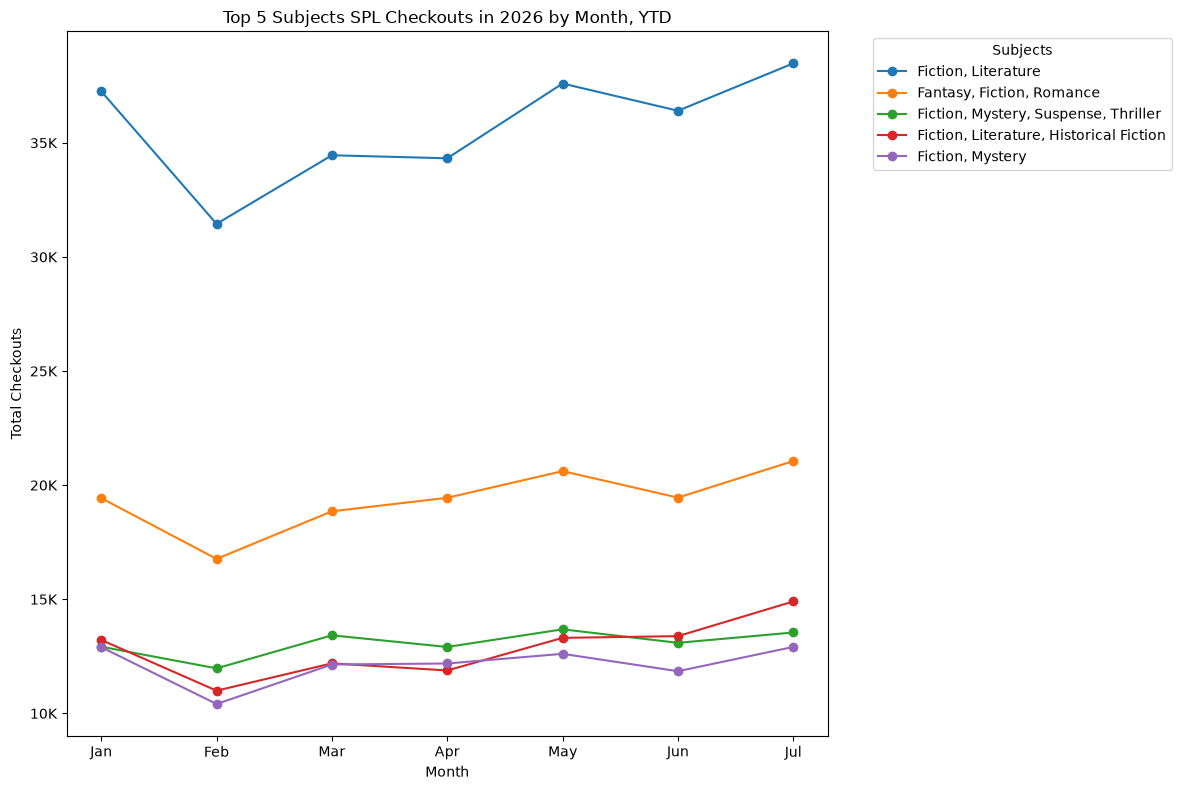

In [31]:
#making a multi-line plot to better represent totals - need to pivot data first

#order the df by desc order
subjects_order=(mom_subjects_totals.groupby("subjects")["total_checkouts"].sum().sort_values(ascending=False).index)

#pivot the data
mom_subjects_totals_pivoted = mom_subjects_totals.pivot_table(
    index="checkoutmonth",
    columns="subjects",
    values="total_checkouts",
    aggfunc="sum")

#organize the data by material type order desc
mom_subjects_totals_pivoted=mom_subjects_totals_pivoted[subjects_order]

#reuse month mapping map across df
mom_subjects_totals_pivoted.index = (
    mom_subjects_totals_pivoted.index
    .map(month_map)
)


#plot it
ax=mom_subjects_totals_pivoted.plot(
    kind="line",
    marker="o",
    figsize=(12,8))


#formatting
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{x/1000:.0f}K')) #turns "200000" into "200k"

plt.legend(title="Subjects", bbox_to_anchor=(1.05,1), loc="upper left") #need a legend for this, tuck it in the corner
plt.xlabel("Month")
plt.ylabel("Total Checkouts")
plt.title("Top 5 Subjects SPL Checkouts in 2026 by Month, YTD")
plt.tight_layout()
plt.show()

Unsurprisingly, fiction is in the top. The first nonfiction category (Cooking & Food) isn't even in the top 10 (#21). 

### Deeper Analysis - Covid-19 Pandemic

#### Part 1 - How People Borrowed

The first pass of data is interesting, but ultimately doesn't tell much:
- There appears to be a seasonality to media checkouts at first glance
- There are evergreen "utility" items showing consistent usage
- Fiction appears to be more popular than nonfiction. 
    
All of these findings could be impacted by availability, but cross-referencing against inventory is a question for another day. If I'm looking for pattern changes during crisis, 2026 is probably not a good baseline year since it's incomplete. The other thing to consider is the question of what constitutes a measurable crisis. One could argue that there's always something going on, but not all events have a direct impact on checkouts. 

The Covid-19 pandemic would be a good event to look at first, since it had a direct impact on library accessibility. Therefore, a good baseline might be:
- 2018-2019 for pre-Covid data
- 2020-2021 for Covid data
- 2022-2023 for Covid recovery
- 2024-2025 for post-Covid data and comparisons to baseline.

If that's where I'm going to start, then the first step is to pull data for this time period and expand my bronze/silver/gold layers accordingly.

In [3]:
#bronze layer
base_url = "https://data.seattle.gov/resource/tmmm-ytt6.json" #base url for API call
all_results = []
for year in range(2018, 2026): #2026 excl
    
    result=data_download(base_url, checkoutyear=year)
    all_results.append(result)
    print(f"Year {result['year']} complete: "
          f"{result['rows']:,} rows, "
          f"{result['files']} parquet files")

Skipping offset 0 because spl_checkouts_2018_0.parquet already exists.
Skipping offset 100,000 because spl_checkouts_2018_100000.parquet already exists.
Skipping offset 200,000 because spl_checkouts_2018_200000.parquet already exists.
Skipping offset 300,000 because spl_checkouts_2018_300000.parquet already exists.
Skipping offset 400,000 because spl_checkouts_2018_400000.parquet already exists.
Skipping offset 500,000 because spl_checkouts_2018_500000.parquet already exists.
Skipping offset 600,000 because spl_checkouts_2018_600000.parquet already exists.
Skipping offset 700,000 because spl_checkouts_2018_700000.parquet already exists.
Skipping offset 800,000 because spl_checkouts_2018_800000.parquet already exists.
Skipping offset 900,000 because spl_checkouts_2018_900000.parquet already exists.
Skipping offset 1,000,000 because spl_checkouts_2018_1000000.parquet already exists.
Skipping offset 1,100,000 because spl_checkouts_2018_1100000.parquet already exists.
Skipping offset 1,200

Downloaded offset 2,500,000, spl_checkouts_2022_2500000.parquet.
Year 2022 complete: 2,531,508 rows, 26 parquet files
Downloaded offset 0, spl_checkouts_2023_0.parquet.
Downloaded offset 100,000, spl_checkouts_2023_100000.parquet.
Downloaded offset 200,000, spl_checkouts_2023_200000.parquet.
Downloaded offset 300,000, spl_checkouts_2023_300000.parquet.
Downloaded offset 400,000, spl_checkouts_2023_400000.parquet.
Downloaded offset 500,000, spl_checkouts_2023_500000.parquet.
Downloaded offset 600,000, spl_checkouts_2023_600000.parquet.
Downloaded offset 700,000, spl_checkouts_2023_700000.parquet.
Downloaded offset 800,000, spl_checkouts_2023_800000.parquet.
Downloaded offset 900,000, spl_checkouts_2023_900000.parquet.
Downloaded offset 1,000,000, spl_checkouts_2023_1000000.parquet.
Downloaded offset 1,100,000, spl_checkouts_2023_1100000.parquet.
Downloaded offset 1,200,000, spl_checkouts_2023_1200000.parquet.
Downloaded offset 1,300,000, spl_checkouts_2023_1300000.parquet.
Downloaded of

In [6]:
#silver layer
for year in range(2018, 2026): #2026 excl
    silver_layer(year)

Created cache/silver/checkouts_clean_2018.parquet
Created cache/silver/checkouts_clean_2019.parquet
Created cache/silver/checkouts_clean_2020.parquet
Created cache/silver/checkouts_clean_2021.parquet
Created cache/silver/checkouts_clean_2022.parquet
Created cache/silver/checkouts_clean_2023.parquet
Created cache/silver/checkouts_clean_2024.parquet
Created cache/silver/checkouts_clean_2025.parquet


In [ ]:
#gold layer
build_material_trends("cache/silver/checkouts_clean_*.parquet")
build_subject_trends("cache/silver/checkouts_clean_*.parquet")
build_title_trends("cache/silver/checkouts_clean_*.parquet")


Let's re-plot the graphs from 2026 and do some side-by-sides with pre-covid, covid, recovery, and post-covid to see what shakes out. I'm also going to add some tags to group years by period for easier color-coding. One thing to note is that from May-July 2024, the Seattle Public Library experienced a ransomware attack that took down the computer systems. Checkouts were still happening manually, but some electronic data was irrevocably lost. This will have to be treated carefully when trying to extrapolate averages for the post-covid time period. For now, I've decided to NULL out those values, so there will be a gap in 2024. When I go to calculate averages for this time period, the mean() function should account for the NULLs.

In [3]:
#total checkouts MoM for each year 
monthly_totals_by_year = duckdb.sql("""
WITH monthly_totals AS(
SELECT checkoutyear
    , checkoutmonth
    , CASE 
        WHEN checkoutyear BETWEEN 2018 AND 2019 THEN 'Pre-Covid'
        WHEN checkoutyear BETWEEN 2020 AND 2021 THEN 'Covid'
        WHEN checkoutyear BETWEEN 2022 AND 2023 THEN 'Recovery'
        WHEN checkoutyear BETWEEN 2024 AND 2025 THEN 'Post-Covid'
        ELSE 'Other' END as timeperiod
    , CASE WHEN checkoutmonth = 1 then 'Jan'
           WHEN checkoutmonth = 2 then 'Feb'
           WHEN checkoutmonth = 3 then 'Mar'
           WHEN checkoutmonth = 4 then 'Apr'
           WHEN checkoutmonth = 5 then 'May'
           WHEN checkoutmonth = 6 then 'Jun'
           WHEN checkoutmonth = 7 then 'Jul'
           WHEN checkoutmonth = 8 then 'Aug'
           WHEN checkoutmonth = 9 then 'Sep'
           WHEN checkoutmonth = 10 then 'Oct'
           WHEN checkoutmonth = 11 then 'Nov'
           WHEN checkoutmonth = 12 then 'Dec'
           ELSE NULL END as month_name
    , SUM(sum_checkouts) as sum_checkouts
FROM 'cache/gold/material_trends_by_year_and_month.parquet'
WHERE checkoutyear BETWEEN 2018 and 2025
GROUP BY 1,2,3,4
)

SELECT checkoutyear
    , checkoutmonth
    , timeperiod
    , month_name
    , CASE WHEN checkoutyear = 2024 and checkoutmonth in (5,6,7) THEN TRUE ELSE FALSE END AS ransomware_gap
    , CASE WHEN checkoutyear = 2024 and checkoutmonth in (5,6,7) THEN NULL ELSE sum_checkouts END as sum_checkouts
    from monthly_totals
    order by checkoutyear, checkoutmonth


""").df()

monthly_totals_by_year


,checkoutyear,checkoutmonth,timeperiod,month_name,ransomware_gap,sum_checkouts
0,2018,1,Pre-Covid,Jan,False,824500.0
1,2018,2,Pre-Covid,Feb,False,726732.0
2,2018,3,Pre-Covid,Mar,False,800357.0
3,2018,4,Pre-Covid,Apr,False,762282.0
4,2018,5,Pre-Covid,May,False,728675.0
...,...,...,...,...,...,...
91,2025,8,Post-Covid,Aug,False,822997.0
92,2025,9,Post-Covid,Sep,False,787867.0
93,2025,10,Post-Covid,Oct,False,786475.0
94,2025,11,Post-Covid,Nov,False,792695.0


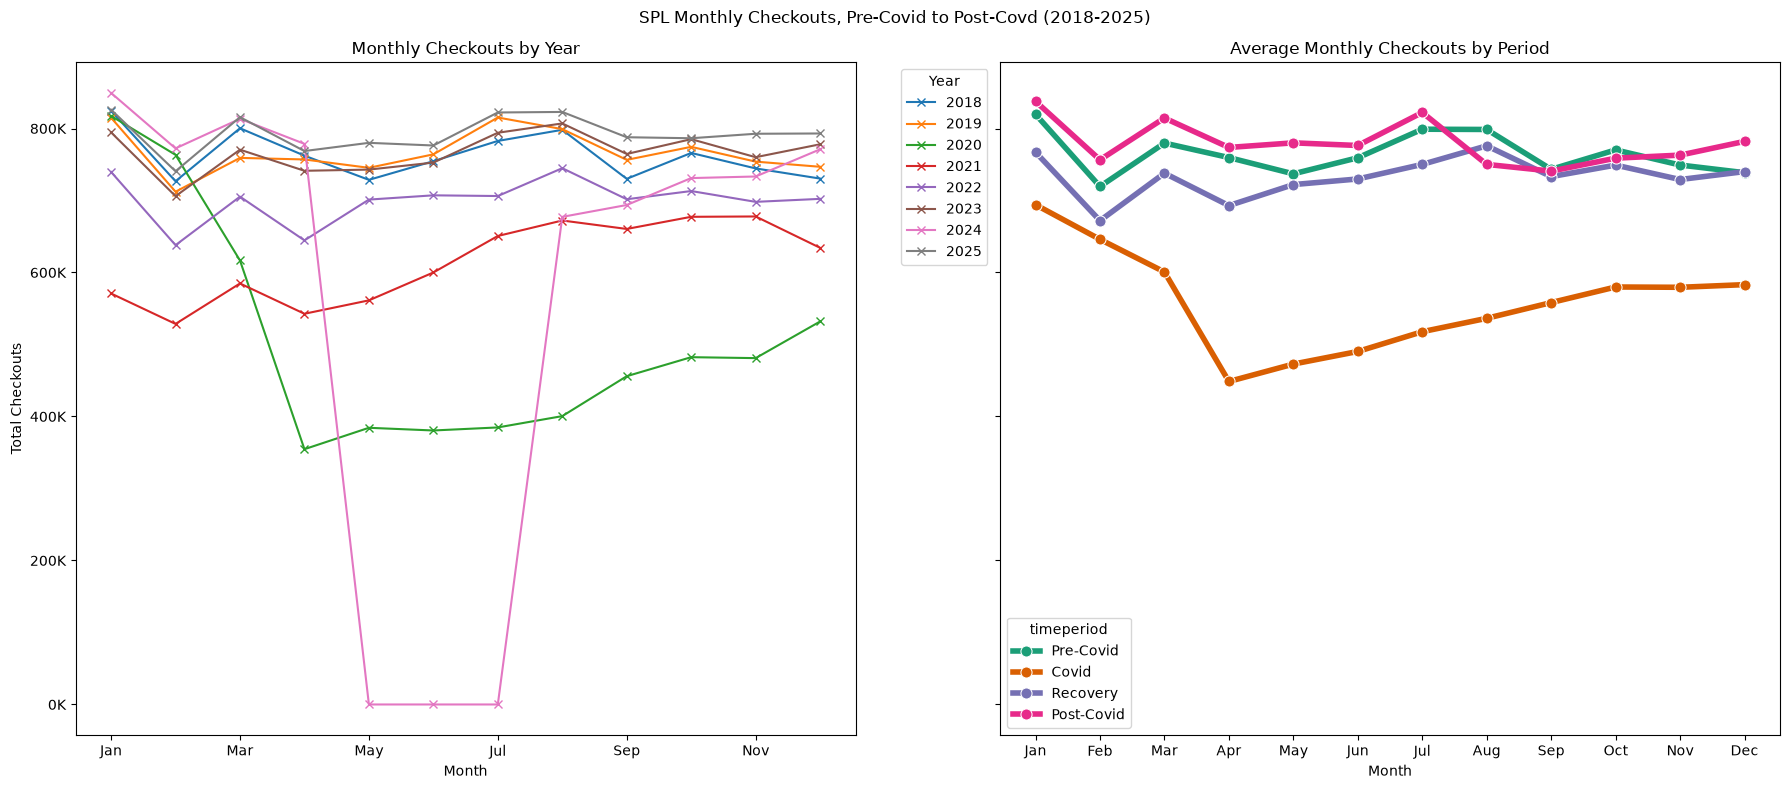

In [4]:
#start by building out some averages for each time period
period_avg = (monthly_totals_by_year.query("ransomware_gap==False").groupby(['timeperiod', 'checkoutmonth', 'month_name'], as_index=False)['sum_checkouts'].mean())

#make sure month names are displayed in order 
month_order = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
period_avg["month_name"] = pd.Categorical(period_avg["month_name"], categories=month_order, ordered=True)
#period order
period_order = ["Pre-Covid","Covid","Recovery","Post-Covid"]
period_avg["timeperiod"] = pd.Categorical(period_avg["timeperiod"],categories=period_order,ordered=True)

#pivot the data
monthly_totals_by_year_pivoted = (
    monthly_totals_by_year.pivot_table (
        index="month_name",
        columns="checkoutyear",
        values="sum_checkouts",
        aggfunc="sum"
    ).reindex(month_order)
)

#plot side-by-sides
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(18,8), sharey=True)

#left chart - individual years
monthly_totals_by_year_pivoted.plot(ax=ax1, marker="x")
ax1.set_title("Monthly Checkouts by Year")
ax1.set_xlabel("Month")
ax1.set_ylabel("Total Checkouts")
ax1.legend(title="Year",bbox_to_anchor=(1.05, 1),loc="upper left")

#Right chart - averages by time period
#sns is a better tool for the job than matplotlib for color-coding by time period

#define different colors for easier readability - otherwise they're both using default palettes
period_colors = {
    "Pre-Covid": "#1b9e77",   # teal
    "Covid": "#d95f02",       # orange
    "Recovery": "#7570b3",    # purple
    "Post-Covid": "#e7298a"   # magenta
}

sns.lineplot(
data=period_avg,
x='month_name',
y='sum_checkouts',
hue='timeperiod',
hue_order=period_order,
marker="o",
linewidth=4, #make the lines thicker to indicate time periods containing multiple years vs individual years
markersize=8, #make the markers bigger, ''
ax=ax2,
palette=period_colors)

ax2.set_title("Average Monthly Checkouts by Period")
ax2.set_xlabel("Month")
ax2.set_ylabel("")

#make y-axis pretty
for ax in [ax1, ax2]:
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f"{x/1000:.0f}K"))

#add supertitle
plt.suptitle("SPL Monthly Checkouts, Pre-Covid to Post-Covd (2018-2025)")
plt.tight_layout()
plt.show()

It looks like, ransomware attack notwithstanding, library checkouts in the post-covid area are even higher than pre-covid levels. Covid certainly impacted checkouts, which makes sense. 2020 was the obviously the most heavily impacted year. After that, the levels began to climb back in 2021, although it took until 2024 before levels fully bounced back to what they were in 2018.

Let's look at material types across the years and across time periods to see if there were differences in the types of materials people used.

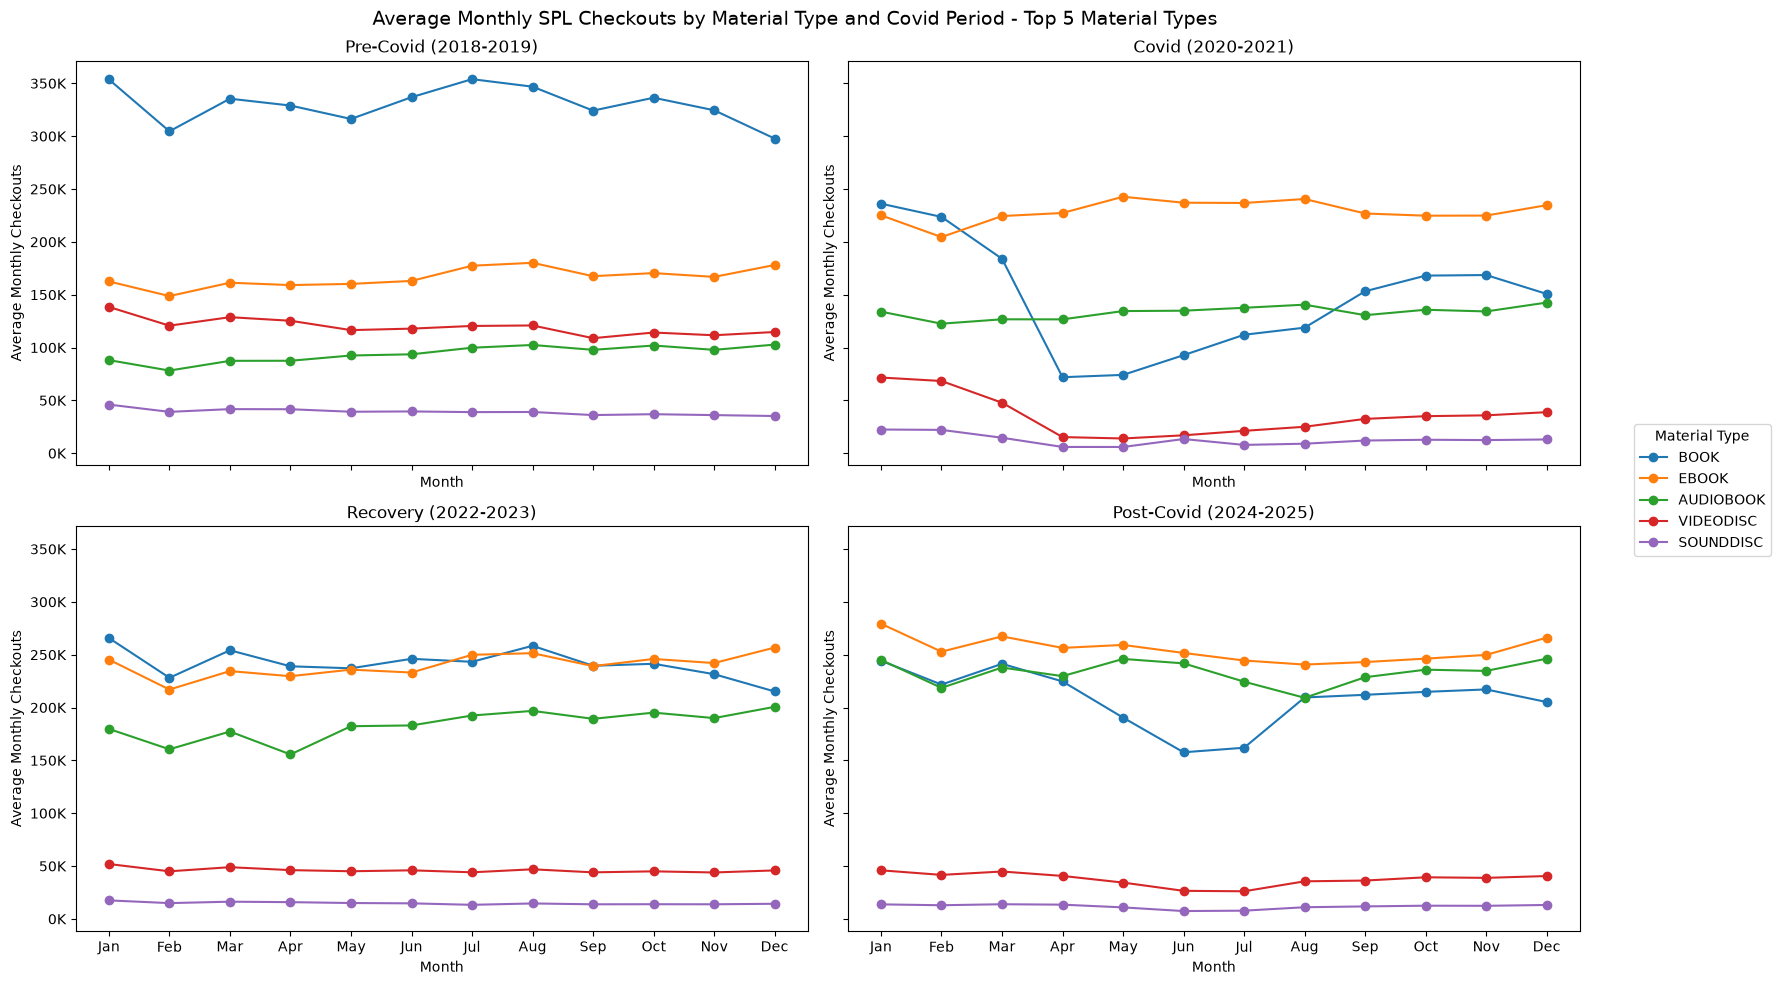

In [22]:
#View 1 - facet by time period, lines by material type

#initial query - material types
mom_material_by_period = duckdb.sql("""
SELECT
    checkoutyear,
    checkoutmonth,
    materialtype,
    CASE 
        WHEN checkoutyear BETWEEN 2018 AND 2019 THEN 'Pre-Covid (2018-2019)'
    
        WHEN checkoutyear BETWEEN 2020 AND 2021 THEN 'Covid (2020-2021)'
        WHEN checkoutyear BETWEEN 2022 AND 2023 THEN 'Recovery (2022-2023)'
        WHEN checkoutyear BETWEEN 2024 AND 2025 THEN 'Post-Covid (2024-2025)'
        ELSE 'Other'
    END AS timeperiod,
    CASE WHEN checkoutmonth = 1 then 'Jan'
           WHEN checkoutmonth = 2 then 'Feb'
           WHEN checkoutmonth = 3 then 'Mar'
           WHEN checkoutmonth = 4 then 'Apr'
           WHEN checkoutmonth = 5 then 'May'
           WHEN checkoutmonth = 6 then 'Jun'
           WHEN checkoutmonth = 7 then 'Jul'
           WHEN checkoutmonth = 8 then 'Aug'
           WHEN checkoutmonth = 9 then 'Sep'
           WHEN checkoutmonth = 10 then 'Oct'
           WHEN checkoutmonth = 11 then 'Nov'
           WHEN checkoutmonth = 12 then 'Dec'
           ELSE NULL END as month_name,
    SUM(sum_checkouts) AS total_checkouts
FROM 'cache/gold/material_trends_by_year_and_month.parquet'
WHERE checkoutyear BETWEEN 2018 AND 2025
GROUP BY 1,2,3,4,5
ORDER BY
    checkoutyear,
    checkoutmonth,
    materialtype
""").df()

#group by time periods
period_material_monthly = (
    mom_material_by_period
    .groupby(
        ["timeperiod", "checkoutmonth", "materialtype", "month_name"],
        as_index=False
    )
    ["total_checkouts"]
    .mean()
)

#just grab top 5 materials, probably don't need everything
top_materials = (
    period_material_monthly
    .groupby("materialtype")["total_checkouts"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)
#make it a list
top_materials_order = list(top_materials)



#filter time periods by top materials
period_material_top = period_material_monthly[
    period_material_monthly["materialtype"].isin(top_materials)
].copy()

#set period order
period_order = [
    "Pre-Covid (2018-2019)",
    "Covid (2020-2021)",
    "Recovery (2022-2023)",
    "Post-Covid (2024-2025)"
]

#create a 2x2 plot with shared axes
fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(16, 10),
    sharex=True,
    sharey=True
)
#changes it from a 2x2 array to a 1x4 array
axes = axes.flatten()

#went back and defined a color map because for some reason it was assigning colors by value not by type
color_map = {
    material: color
    for material, color in zip(
        top_materials_order,
        plt.cm.tab10.colors
    )
}

#knits the 2x2 graphs to each time period, in the order they occurred
for ax, period in zip(axes, period_order):

    subset = period_material_top[
        period_material_top["timeperiod"] == period #loops through each time period
        ]
#pivoting data so that material types are the cols and the months are the rows - easier plotting
    pivoted = subset.pivot_table(
        index="checkoutmonth",
        columns="materialtype",
        values="total_checkouts",
        aggfunc="first"
    )
    
    #add month_mapping so it's the friendly name
    pivoted = pivoted.sort_index()
    pivoted = pivoted.reindex(columns=top_materials_order)
    pivoted.index = pivoted.index.map(month_map)
    
    for material in top_materials_order:
        ax.plot(pivoted.index,
                pivoted[material],
                marker="o",
                label=material,
                color=color_map[material]
               )
        
        
    #formatting
    ax.set_title(period)
    ax.set_xlabel("Month")
    ax.set_ylabel("Average Monthly Checkouts")
    ax.yaxis.set_major_formatter(
        FuncFormatter(lambda x, p: f"{x/1000:.0f}K")
    )

# shared legend - steals info from 1st chart, since they all share axes anyway
handles, labels = axes[0].get_legend_handles_labels()

#format the legend
fig.legend(
    handles, #use same colored lines across graphs 
    labels, #use same labels
    title="Material Type",
    bbox_to_anchor=(1.02, 0.5),
    loc="center left" 
)

fig.suptitle(
    "Average Monthly SPL Checkouts by Material Type and Covid Period - Top 5 Material Types",
    fontsize=14
)

plt.tight_layout()
plt.show()

This is fascinating and not what I thought I'd see. 
- Pre-Covid (2018-2019) shows print books as the dominant material type by a wide margin. Ebooks are already popular during this period, but they remain a distant second to physical books.
- Covid (2020-2021) is where the most dramatic shift occurs. Print book checkouts drop sharply while ebooks become the most heavily used format. Videodiscs also decline significantly. While this likely reflects changes in how people accessed library materials during the pandemic, the data alone doesn't tell us whether the change was driven by patron preference, access limitations, or some combination of the two.
- Recovery (2022-2023) shows a strong rebound in physical book checkouts, but not a return to pre-Covid levels. Digital formats remain elevated, suggesting that at least some of the borrowing habits formed during the pandemic may have persisted.
- Post-Covid (2024-2025) continues that trend. Print books stabilize below their pre-pandemic average, while ebooks and audiobooks remain highly utilized. At first glance, this suggests the pandemic may have accelerated an existing shift toward digital borrowing rather than creating a temporary disruption that later reverted.
- One of the more surprising findings is how little month-to-month variation exists within each period. The overall shape of the year remains fairly consistent, while the relative popularity of different material types changes substantially between periods.


What happens if I look at material type checkouts as a % of total checkouts? That would be a little clearer than just "ebooks were popular".

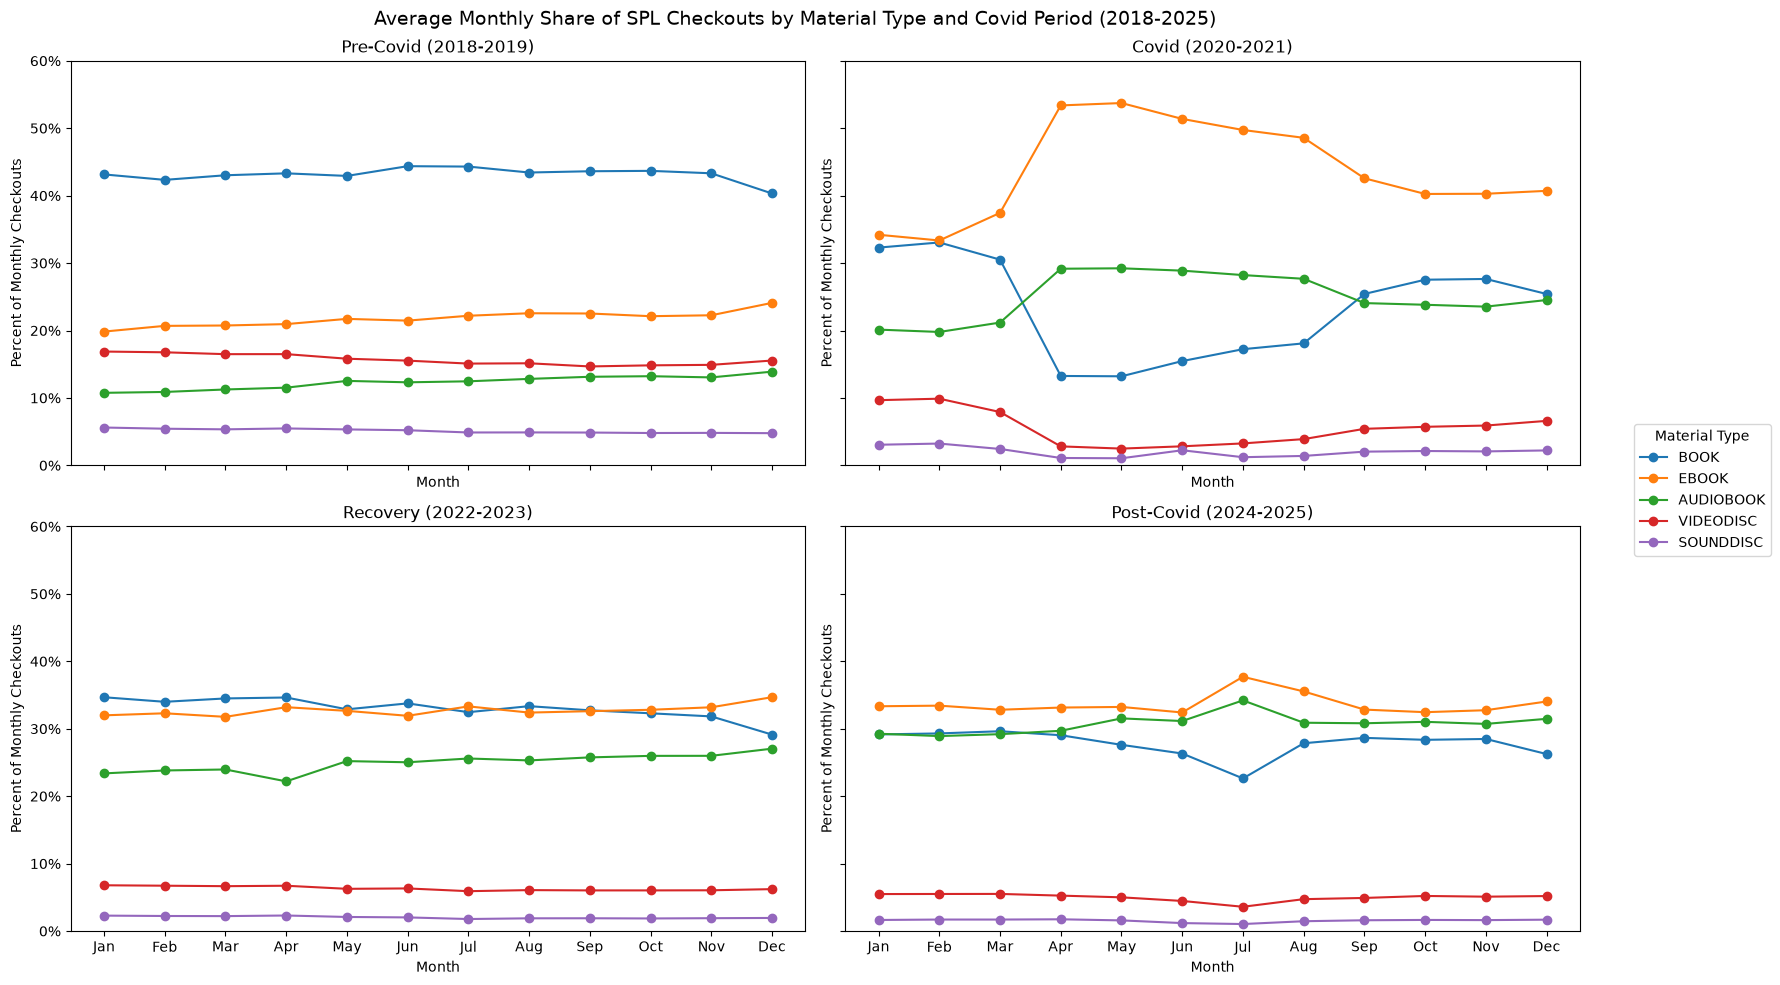

In [2]:
#View 2 - get material percentages by time period
material_share_by_period = duckdb.sql("""
WITH monthly_material AS (
    SELECT
        checkoutyear,
        checkoutmonth,
        materialtype,

        CASE
        WHEN checkoutyear BETWEEN 2018 AND 2019 THEN 'Pre-Covid (2018-2019)'
        WHEN checkoutyear BETWEEN 2020 AND 2021 THEN 'Covid (2020-2021)'
        WHEN checkoutyear BETWEEN 2022 AND 2023 THEN 'Recovery (2022-2023)'
        WHEN checkoutyear BETWEEN 2024 AND 2025 THEN 'Post-Covid (2024-2025)'
            ELSE 'Other'
        END AS timeperiod,

        SUM(sum_checkouts) AS material_checkouts

    FROM 'cache/gold/material_trends_by_year_and_month.parquet'

    WHERE checkoutyear BETWEEN 2018 AND 2025

    GROUP BY
        checkoutyear,
        checkoutmonth,
        materialtype,
        timeperiod
),

monthly_totals AS (
    SELECT
        checkoutyear,
        checkoutmonth,
        timeperiod,
        SUM(material_checkouts) AS monthly_total_checkouts

    FROM monthly_material

    GROUP BY
        checkoutyear,
        checkoutmonth,
        timeperiod
),

material_share AS (
    SELECT
        m.checkoutyear,
        m.checkoutmonth,
        m.timeperiod,
        m.materialtype,
        m.material_checkouts,
        t.monthly_total_checkouts,

        100.0 * m.material_checkouts
        / t.monthly_total_checkouts
        AS pct_of_monthly_checkouts

    FROM monthly_material AS m

    INNER JOIN monthly_totals AS t
        ON m.checkoutyear = t.checkoutyear
       AND m.checkoutmonth = t.checkoutmonth
       AND m.timeperiod = t.timeperiod
)

SELECT *
FROM material_share

ORDER BY
    checkoutyear,
    checkoutmonth,
    materialtype
""").df()


# Average percentages across years within each time period
period_material_share = (
    material_share_by_period
    .groupby(
        [
            "timeperiod",
            "checkoutmonth",
            "materialtype"
        ],
        as_index=False
    )
    ["pct_of_monthly_checkouts"]
    .mean()
)


# Use same top materials as previous chart
top_materials_order = [
    "BOOK",
    "EBOOK",
    "AUDIOBOOK",
    "VIDEODISC",
    "SOUNDDISC"
]

# Filter dataset to those material types
period_material_share_top = (
    period_material_share[
        period_material_share["materialtype"]
        .isin(top_materials_order)
    ]
    .copy()
)


# Month labels
month_map = {
    1: "Jan",
    2: "Feb",
    3: "Mar",
    4: "Apr",
    5: "May",
    6: "Jun",
    7: "Jul",
    8: "Aug",
    9: "Sep",
    10: "Oct",
    11: "Nov",
    12: "Dec"
}


# Time period ordering
period_order = [
    "Pre-Covid (2018-2019)",
    "Covid (2020-2021)",
    "Recovery (2022-2023)",
    "Post-Covid (2024-2025)"
]


# Create 2x2 grid
fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(16, 10),
    sharex=True,
    sharey=True
)

axes = axes.flatten()


# Consistent material colors
color_map = {
    material: color
    for material, color in zip(
        top_materials_order,
        plt.cm.tab10.colors
    )
}


# Plot each facet
for ax, period in zip(axes, period_order):

    subset = period_material_share_top[
        period_material_share_top["timeperiod"] == period
    ]

    pivoted = subset.pivot_table(
        index="checkoutmonth",
        columns="materialtype",
        values="pct_of_monthly_checkouts",
        aggfunc="first"
    )

    pivoted = pivoted.sort_index()

    pivoted = pivoted.reindex(
        columns=top_materials_order
    )

    pivoted.index = (
        pivoted.index.map(month_map)
    )

    for material in top_materials_order:

        ax.plot(
            pivoted.index,
            pivoted[material],
            marker="o",
            label=material,
            color=color_map[material]
        )

    ax.set_title(period)
    ax.set_xlabel("Month")
    ax.set_ylabel("Percent of Monthly Checkouts")

    ax.set_ylim(0, 60)

    ax.yaxis.set_major_formatter(
        FuncFormatter(
            lambda x, p: f"{x:.0f}%"
        )
    )


# Shared legend
handles, labels = (
    axes[0]
    .get_legend_handles_labels()
)

fig.legend(
    handles,
    labels,
    title="Material Type",
    bbox_to_anchor=(1.02, 0.5),
    loc="center left"
)


# Title
fig.suptitle(
    "Average Monthly Share of SPL Checkouts by Material Type and Covid Period (2018-2025)",
    fontsize=14
)

plt.tight_layout()
plt.show()

The percent-share view makes the change feel even more dramatic than the raw checkout totals. 
- Before Covid, print books consistently accounted for the largest share of monthly checkouts (~40%), while ebooks and audiobooks were meaningful but clearly secondary. 
- During Covid, that relationship flips: ebooks become the largest share of checkouts, while print books drop sharply, especially during the early pandemic months. 
- Recovery does not look like a simple return to the pre-Covid pattern. Instead, books, ebooks, and audiobooks become much more evenly distributed. 
- By the post-Covid period, ebooks and audiobooks remain highly prominent, while print books stabilize at a lower share than they held before the pandemic. This suggests that Covid may have accelerated an existing shift toward digital borrowing rather than causing a temporary change that fully reversed afterward.

*One note: I set the upper limit on the y-axis to 60% just for readability.*

#### Part 2 - What People Borrowed
This is really interesting and answers some good questions about *how* people borrowed. Now I want to take a look at *what* they borrowed, and if there were changes across time periods.

Let's start by just getting a Top 10 list of subjects borrowed during the entire date range.

UPDATE: Unfortunately this is where I started running into issues. It turns out that the data for Subjects is actually a metadata-concatenated string of every catalogue value associated with every title. What that means is that the data is not structured:
- Fantasy
- Horror
- Nonfiction
- etc

It's actually:


- 87th Precinct Imaginary place Fiction, City and town life Fiction, Police Fiction, Mystery fiction
- 87th Precinct Imaginary place Fiction, Police United States Fiction, Detective and mystery fiction
- 87th Precinct Imaginary place Fiction, Police United States Fiction, Large type books, Detective and mystery fiction
- 87th Precinct Imaginary place Fiction, Police United States Fiction, Mystery fiction
- etc

Across the time periods I'm looking at, it's ~534k unique values. In addition, it looks like genre, subject, topic, and intended audience are all mixed into the same string. This is not something I can realistically build a gold layer off of. After looking deeper into the years, it looks like the library may have changed their cataloguing structure over the time periods. So a book may have started with "87th Precinct Imaginary place Fiction, City and town life Fiction, Police Fiction, Mystery fiction" in 2018 but by the time 2025 comes through, it's just "Fiction". So this is going to make things a bit tricky. 

I think a way to start may be to get the top 10 Subjects across all time periods, and then track their movement over time across each. It's not a perfect approach but for a first pass methodology it may at least show the difference in categorizations over time. 


In [3]:
#get top 10 subjects across all time periods
top_10_subjects_overall = duckdb.sql("""
SELECT
    COALESCE(subjects, '[Unknown]') AS subjects,
    SUM(checkouts) AS total_checkouts
FROM read_parquet(
    'cache/silver/checkouts_clean_*.parquet',
    union_by_name = true
)
WHERE checkoutyear BETWEEN 2018 AND 2025
GROUP BY
    COALESCE(subjects, '[Unknown]')
ORDER BY
    total_checkouts DESC
LIMIT 10
""").df()

top_10_subjects_overall

,subjects,total_checkouts
0,"Fiction, Literature",2485563.0
1,"Fiction, Mystery",1158924.0
2,"Fiction, Mystery, Suspense, Thriller",951348.0
3,"Juvenile Fiction, Juvenile Literature",678810.0
4,"Fiction, Suspense, Thriller",670139.0
5,"Fiction, Literature, Historical Fiction",616387.0
6,"Fiction, Literature, Romance",615389.0
7,"Fiction, Literature, Suspense, Thriller",544737.0
8,[Unknown],539608.0
9,"Fantasy, Fiction, Romance",522149.0


"Unknown" is a huge category. That's...inconvenient.

In [5]:
#track MoM activity for top 10 
top_10_subject_trends = duckdb.sql("""
WITH top_subjects AS (
    SELECT
        COALESCE(subjects, '[Unknown]') AS subjects,
        SUM(checkouts) AS total_checkouts
    FROM read_parquet(
        'cache/silver/checkouts_clean_*.parquet',
        union_by_name = true
    )
    WHERE checkoutyear BETWEEN 2018 AND 2025
    GROUP BY
        COALESCE(subjects, '[Unknown]')
    ORDER BY
        total_checkouts DESC
    LIMIT 10
),

monthly_subjects AS (
    SELECT
        checkoutyear,
        checkoutmonth,

        CASE
            WHEN checkoutyear BETWEEN 2018 AND 2019
                THEN 'Pre-Covid'
            WHEN checkoutyear BETWEEN 2020 AND 2021
                THEN 'Covid'
            WHEN checkoutyear BETWEEN 2022 AND 2023
                THEN 'Recovery'
            WHEN checkoutyear BETWEEN 2024 AND 2025
                THEN 'Post-Covid'
            ELSE 'Other'
        END AS timeperiod,

        COALESCE(subjects, '[Unknown]') AS subjects,
        SUM(checkouts) AS subject_checkouts

    FROM read_parquet(
        'cache/silver/checkouts_clean_*.parquet',
        union_by_name = true
    )

    WHERE checkoutyear BETWEEN 2018 AND 2025
      AND COALESCE(subjects, '[Unknown]') IN (
          SELECT subjects
          FROM top_subjects
      )

    GROUP BY
        checkoutyear,
        checkoutmonth,
        timeperiod,
        COALESCE(subjects, '[Unknown]')
)

SELECT
    checkoutyear,
    checkoutmonth,
    timeperiod,
    subjects,
    subject_checkouts
FROM monthly_subjects
ORDER BY
    checkoutyear,
    checkoutmonth,
    subject_checkouts DESC
""").df()

#top_10_subject_trends

,checkoutyear,checkoutmonth,timeperiod,subjects,subject_checkouts
0,2018,1,Pre-Covid,[Unknown],27366.0
1,2018,1,Pre-Covid,"Fiction, Literature",16848.0
2,2018,1,Pre-Covid,"Fiction, Mystery",11746.0
3,2018,1,Pre-Covid,"Fiction, Mystery, Suspense, Thriller",6431.0
4,2018,1,Pre-Covid,"Fiction, Suspense, Thriller",4617.0
...,...,...,...,...,...
916,2025,12,Post-Covid,"Fiction, Suspense, Thriller",11103.0
917,2025,12,Post-Covid,"Fiction, Literature, Romance",9069.0
918,2025,12,Post-Covid,"Fiction, Literature, Suspense, Thriller",7966.0
919,2025,12,Post-Covid,[Unknown],7930.0


In [6]:
#average across years to get time period avgs
period_subject_monthly = (
    top_10_subject_trends
    .groupby(
        [
            "timeperiod",
            "checkoutmonth",
            "subjects"
        ],
        as_index=False
    )["subject_checkouts"]
    .mean()
)

#period_subject_monthly

,timeperiod,checkoutmonth,subjects,subject_checkouts
0,Covid,1,"Fantasy, Fiction, Romance",2743.0
1,Covid,1,"Fiction, Literature",26407.5
2,Covid,1,"Fiction, Literature, Romance",5056.5
3,Covid,1,"Fiction, Literature, Suspense, Thriller",3931.0
4,Covid,1,"Fiction, Mystery",12619.0
...,...,...,...,...
460,Recovery,12,"Fiction, Mystery",13122.5
461,Recovery,12,"Fiction, Mystery, Suspense, Thriller",12126.5
462,Recovery,12,"Fiction, Suspense, Thriller",8025.0
463,Recovery,12,"Juvenile Fiction, Juvenile Literature",7546.5


In [13]:
#rank them
top_10_by_period = duckdb.sql("""
WITH subject_period_totals AS (
    SELECT
        CASE
            WHEN checkoutyear BETWEEN 2018 AND 2019
                THEN 'Pre-Covid (2018-2019)'
            WHEN checkoutyear BETWEEN 2020 AND 2021
                THEN 'Covid (2020-2021)'
            WHEN checkoutyear BETWEEN 2022 AND 2023
                THEN 'Recovery (2022-2023)'
            WHEN checkoutyear BETWEEN 2024 AND 2025
                THEN 'Post-Covid (2024-2025)'
            ELSE 'Other'
        END AS timeperiod,

        COALESCE(subjects, '[Unknown]') AS subjects,
        SUM(checkouts) AS total_checkouts

    FROM read_parquet(
        'cache/silver/checkouts_clean_*.parquet',
        union_by_name = true
    )

    WHERE checkoutyear BETWEEN 2018 AND 2025

    GROUP BY
        timeperiod,
        COALESCE(subjects, '[Unknown]')
),

ranked_subjects AS (
    SELECT
        timeperiod,
        subjects,
        total_checkouts,

        ROW_NUMBER() OVER (
            PARTITION BY timeperiod
            ORDER BY total_checkouts DESC
        ) AS subject_rank

    FROM subject_period_totals
)

SELECT
    timeperiod,
    subject_rank,
    subjects,
    total_checkouts
FROM ranked_subjects
WHERE subject_rank <= 10
ORDER BY
    CASE timeperiod
        WHEN 'Pre-Covid' THEN 1
        WHEN 'Covid' THEN 2
        WHEN 'Recovery' THEN 3
        WHEN 'Post-Covid' THEN 4
        ELSE 5
    END,
    subject_rank
""").df()

#top_10_by_period

,timeperiod,subject_rank,subjects,total_checkouts
0,Pre-Covid (2018-2019),1,"Fiction, Literature",478067.0
1,Recovery (2022-2023),1,"Fiction, Literature",663170.0
2,Post-Covid (2024-2025),1,"Fiction, Literature",716751.0
3,Covid (2020-2021),1,"Fiction, Literature",627575.0
4,Pre-Covid (2018-2019),2,"Fiction, Mystery",277333.0
5,Post-Covid (2024-2025),2,"Fiction, Mystery, Suspense, Thriller",309089.0
6,Recovery (2022-2023),2,"Fiction, Mystery",299251.0
7,Covid (2020-2021),2,"Fiction, Mystery",311060.0
8,Recovery (2022-2023),3,"Fiction, Mystery, Suspense, Thriller",272002.0
9,Post-Covid (2024-2025),3,"Fantasy, Fiction, Romance",298978.0


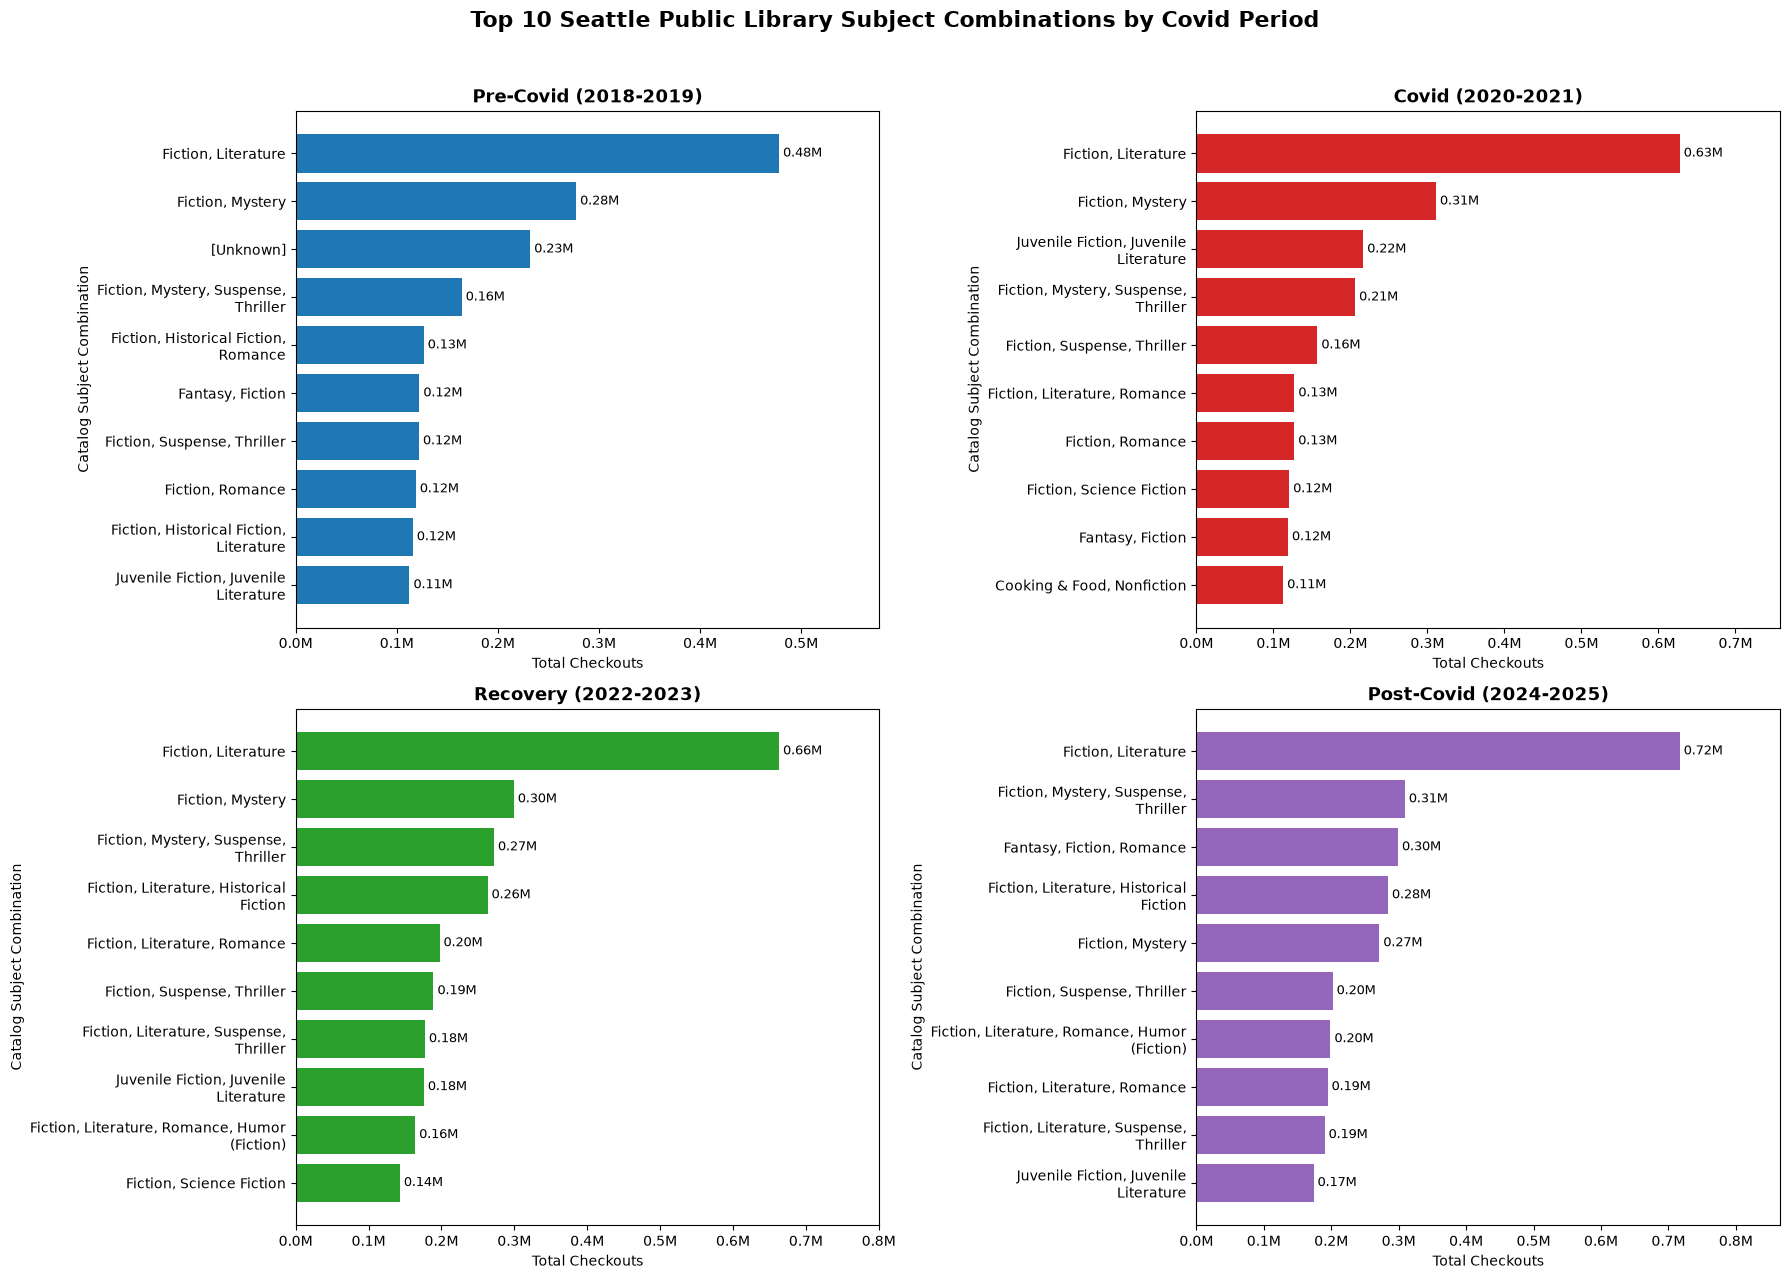

In [14]:
# Set the order in which the four period facets should appear.
period_order = [
    "Pre-Covid (2018-2019)",
    "Covid (2020-2021)",
    "Recovery (2022-2023)",
    "Post-Covid (2024-2025)"
]

# Create one consistent color for each time period.
# This keeps the four facets visually distinct without implying that
# matching bar colors represent the same subject across panels.
period_colors = {
    "Pre-Covid (2018-2019)": "tab:blue",
    "Covid (2020-2021)": "tab:red",
    "Recovery (2022-2023)": "tab:green",
    "Post-Covid (2024-2025)": "tab:purple"
}


# Create a 2x2 grid.
# sharex=False allows each panel to use the most readable checkout scale.
# sharey=False is necessary because each period may have different subjects.
fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(18, 13),
    sharex=False,
    sharey=False
)

# Convert the 2x2 array of axes into a simple list for looping.
axes = axes.flatten()


# Build one horizontal bar chart for each time period.
for ax, period in zip(axes, period_order):

    # Filter the dataset to the current period.
    subset = (
        top_10_by_period[
            top_10_by_period["timeperiod"] == period
        ]
        .copy()
    )

    # Sort largest to smallest.
    # For a horizontal bar chart, ascending order places the largest bar at the top
    # after invert_yaxis() is applied below.
    subset = subset.sort_values(
        "total_checkouts",
        ascending=False
    )

    # Wrap long catalog subject strings across multiple lines.
    # Adjust width=35 if labels need more or less wrapping.
    subset["subject_label"] = subset["subjects"].apply(
        lambda value: "\n".join(
            textwrap.wrap(
                str(value),
                width=35
            )
        )
    )

    # Plot the ranked subject combinations.
    ax.barh(
        subset["subject_label"],
        subset["total_checkouts"],
        color=period_colors[period]
    )

    # Put rank 1 / largest checkout total at the top.
    ax.invert_yaxis()

    # Add the period as the facet title.
    ax.set_title(
        period,
        fontsize=13,
        fontweight="bold"
    )

    # Label axes.
    ax.set_xlabel("Total Checkouts")
    ax.set_ylabel("Catalog Subject Combination")

    # Display large checkout totals in millions where appropriate.
    # Examples: 500000 becomes 0.5M and 2000000 becomes 2.0M.
    ax.xaxis.set_major_formatter(
        FuncFormatter(
            lambda x, p: f"{x / 1_000_000:.1f}M"
        )
    )

    # Add checkout totals at the end of each bar.
    for bar, value in zip(
        ax.patches,
        subset["total_checkouts"]
    ):
        ax.text(
            bar.get_width(),
            bar.get_y() + bar.get_height() / 2,
            f" {value / 1_000_000:.2f}M",
            va="center",
            ha="left",
            fontsize=9
        )

    # Add a little room so the data labels do not get cut off.
    current_left, current_right = ax.get_xlim()
    ax.set_xlim(
        current_left,
        current_right * 1.15
    )


# Add one title across all four panels.
fig.suptitle(
    "Top 10 Seattle Public Library Subject Combinations by Covid Period",
    fontsize=16,
    fontweight="bold"
)


# Adjust spacing for wrapped subject labels and the overall title.
plt.tight_layout(
    rect=[0, 0, 1, 0.96]
)

# Display the figure.
plt.show()

**A couple things immediately stand out:**
- Covid is the only time period where Nonfiction appears in the Top 10.
- "Fiction, Literature" is consistently at the top by an order of magnitude. This to me suggests that it's a generic category that, if we were to take a closer look at those concatenated metadata-strings and/or specific titles, might shed more light. A question for another day.
- "Unknown" is really only present in Pre-Covid, suggesting that the cataloguing structure got more refined over time?
- It's oddly encouraging to see Juvenile Fiction consistently appear in the Top 10 across time periods. Even though I"d consider that a target audience categorization rather than a genre (just an artifact of the data's messiness). 
- It's evident that deeper analysis would require data cleaning that I unfortunately don't have time to do today. For example, "Fiction Literature, Romance" and "Fiction, Romance" could probably be combined into one field, which would change the Top 10 during Covid. Same with "Fiction, Mystery, Suspense-Thriller", "Fiction, Suspense-Thriller", and "Fiction Literature, Suspense-Thriller" during the Recovery period.

### LGBTQIA+ and African-American literature 
One of the last things I want to look at is how specific topics changed over time. Covid brough about a time of massive social change - the George Floyd protests, for example. There were also deep impacts on already-marginalized communities, like LGBTQIA+. **Did borrowing habits change for African-American or LGBTQIA+ literature during this time?**



In [6]:
lgbtq_afam_by_period = duckdb.sql("""
WITH themes AS (

    SELECT
        checkoutyear,
        checkoutmonth,

        CASE
            WHEN checkoutyear BETWEEN 2018 AND 2019
                THEN 'Pre-Covid (2018-2019)'
            WHEN checkoutyear BETWEEN 2020 AND 2021
                THEN 'Covid (2020-2021)'
            WHEN checkoutyear BETWEEN 2022 AND 2023
                THEN 'Recovery (2022-2023)'
            WHEN checkoutyear BETWEEN 2024 AND 2025
                THEN 'Post-Covid (2024-2025)'
            ELSE 'Other'
        END AS timeperiod,

        CASE

            WHEN lower(subjects) LIKE '%african american%'
              OR lower(subjects) LIKE '%african americans%'
              OR lower(subjects) LIKE '%black americans%'
              OR lower(subjects) LIKE '%black people%'
                THEN 'African American'

            WHEN lower(subjects) LIKE '%lgbt%'
              OR lower(subjects) LIKE '%lgbtq%'
              OR lower(subjects) LIKE '%gay%'
              OR lower(subjects) LIKE '%lesbian%'
              OR lower(subjects) LIKE '%bisexual%'
              OR lower(subjects) LIKE '%transgender%'
              OR lower(subjects) LIKE '%queer%'
                THEN 'LGBTQIA+'

            ELSE NULL

        END AS theme,

        SUM(checkouts) AS sum_checkouts

    FROM read_parquet(
        'cache/silver/checkouts_clean_*.parquet',
        union_by_name = true
    )

    WHERE checkoutyear BETWEEN 2018 AND 2025
      AND subjects IS NOT NULL

    GROUP BY
        checkoutyear,
        checkoutmonth,
        timeperiod,
        theme

)

SELECT
    timeperiod,
    theme,
    SUM(sum_checkouts) AS total_checkouts
FROM themes
WHERE theme IS NOT NULL
GROUP BY
    timeperiod,
    theme
ORDER BY
    theme,
    total_checkouts DESC
""").df()

#lgbtq_afam_by_period

,timeperiod,theme,total_checkouts
0,Recovery (2022-2023),African American,377372.0
1,Covid (2020-2021),African American,350159.0
2,Post-Covid (2024-2025),African American,338994.0
3,Pre-Covid (2018-2019),African American,337315.0
4,Post-Covid (2024-2025),LGBTQIA+,508850.0
5,Recovery (2022-2023),LGBTQIA+,409657.0
6,Covid (2020-2021),LGBTQIA+,107958.0
7,Pre-Covid (2018-2019),LGBTQIA+,102416.0


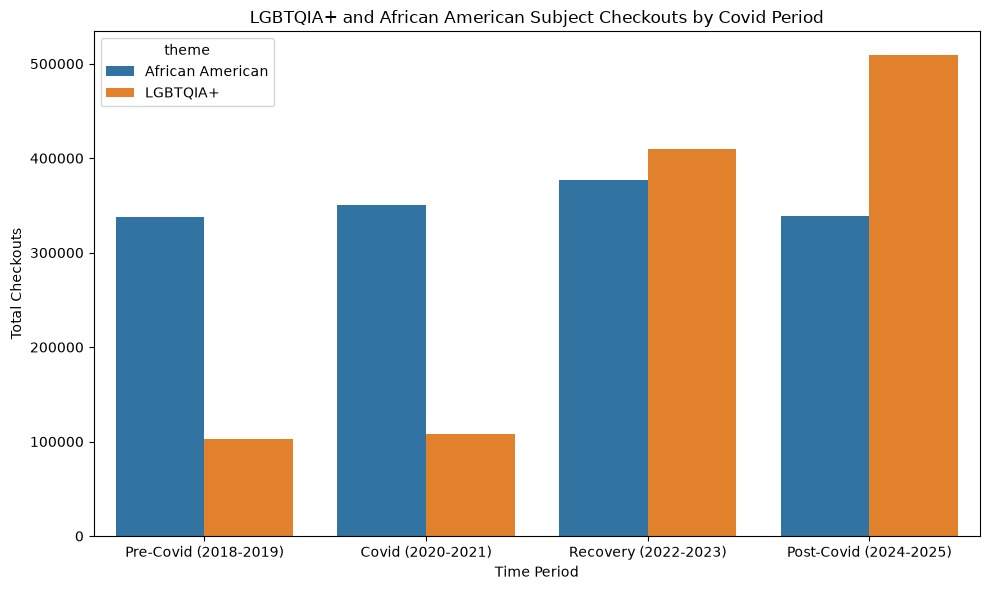

In [7]:
#plot it

period_order = [
    "Pre-Covid (2018-2019)",
    "Covid (2020-2021)",
    "Recovery (2022-2023)",
    "Post-Covid (2024-2025)"
]

lgbtq_afam_by_period["timeperiod"] = pd.Categorical(
    lgbtq_afam_by_period["timeperiod"],
    categories=period_order,
    ordered=True
)

lgbtq_afam_by_period = (
    lgbtq_afam_by_period
    .sort_values("timeperiod")
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=lgbtq_afam_by_period,
    x="timeperiod",
    y="total_checkouts",
    hue="theme",
    order=period_order
)

plt.title(
    "LGBTQIA+ and African American Subject Checkouts by Covid Period"
)

plt.xlabel("Time Period")
plt.ylabel("Total Checkouts")
plt.tight_layout()
plt.show()

Let's look at totals as a % of all checkouts:

In [1]:
def calculate_theme_share_by_year(
    checkoutyear,
    silver_dir="cache/silver"
):
    """
    Calculate monthly total checkouts and matched theme checkouts
    for one year at a time.

    Returns 24 rows:
    12 months x 2 subject themes.
    """

    # grab appropriate silver file for checkoutyear
    input_file = (
        Path(silver_dir)
        / f"checkouts_clean_{checkoutyear}.parquet"
    )

    # Stop if silver file is missing.
    if not input_file.exists():
        raise FileNotFoundError(
            f"No Silver file found for {checkoutyear}: "
            f"{input_file}"
        )

#Total monthly SPL checkouts, THEN AA and LGBT matched checkouts
    yearly_monthly_totals = duckdb.sql(f"""
    SELECT
        TRY_CAST(checkoutyear AS INTEGER) AS checkoutyear,
        TRY_CAST(checkoutmonth AS INTEGER) AS checkoutmonth,

        SUM(checkouts) AS monthly_total_checkouts,

        SUM(
            CASE
                WHEN
                       COALESCE(subjects, '') ILIKE '%african american%'
                    OR COALESCE(subjects, '') ILIKE '%black american%'
                    OR COALESCE(subjects, '') ILIKE '%black people%'
                THEN checkouts
                ELSE 0
            END
        ) AS african_american_checkouts,

        SUM(
            CASE
                WHEN
                       COALESCE(subjects, '') ILIKE '%lgbt%'
                    OR COALESCE(subjects, '') ILIKE '%gay%'
                    OR COALESCE(subjects, '') ILIKE '%lesbian%'
                    OR COALESCE(subjects, '') ILIKE '%bisexual%'
                    OR COALESCE(subjects, '') ILIKE '%transgender%'
                    OR COALESCE(subjects, '') ILIKE '%queer%'
                    OR COALESCE(subjects, '') ILIKE '%nonbinary%'
                    OR COALESCE(subjects, '') ILIKE '%non-binary%'
                THEN checkouts
                ELSE 0
            END
        ) AS lgbtqia_checkouts

    FROM '{input_file}'

    GROUP BY
        TRY_CAST(checkoutyear AS INTEGER),
        TRY_CAST(checkoutmonth AS INTEGER)

    ORDER BY
        checkoutyear,
        checkoutmonth
    """).df()

#pivot
    theme_long = yearly_monthly_totals.melt(
        id_vars=[
            "checkoutyear",
            "checkoutmonth",
            "monthly_total_checkouts"
        ],
        value_vars=[
            "african_american_checkouts",
            "lgbtqia_checkouts"
        ],
        var_name="theme",
        value_name="theme_checkouts"
    )

    # make theme names pretty.
    theme_long["theme"] = theme_long["theme"].map(
        {
            "african_american_checkouts":
                "African American",
            "lgbtqia_checkouts":
                "LGBTQIA+"
        }
    )

    # monthly checkouts by theme
    theme_long["pct_of_monthly_checkouts"] = (
        100.0
        * theme_long["theme_checkouts"]
        / theme_long["monthly_total_checkouts"]
    )

    return theme_long

In [2]:
yearly_theme_results = []


#loop through each year and calc %s
for year in range(2018, 2026):

    print(f"Processing {year}...")

    yearly_result = calculate_theme_share_by_year(
        checkoutyear=year
    )

    yearly_theme_results.append(
        yearly_result
    )

    print(
        f"Completed {year}: "
        f"{len(yearly_result):,} result rows"
    )


#concat results
    yearly_theme_results,
    ignore_index=True
)

#theme_share_by_month.head()

Processing 2018...
Completed 2018: 24 result rows
Processing 2019...
Completed 2019: 24 result rows
Processing 2020...
Completed 2020: 24 result rows
Processing 2021...
Completed 2021: 24 result rows
Processing 2022...
Completed 2022: 24 result rows
Processing 2023...
Completed 2023: 24 result rows
Processing 2024...
Completed 2024: 24 result rows
Processing 2025...
Completed 2025: 24 result rows


,checkoutyear,checkoutmonth,monthly_total_checkouts,theme,theme_checkouts,pct_of_monthly_checkouts
0,2018,1,824500.0,African American,12309.0,1.492905
1,2018,2,726732.0,African American,13137.0,1.807682
2,2018,3,800357.0,African American,13447.0,1.680125
3,2018,4,762282.0,African American,13134.0,1.722984
4,2018,5,728675.0,African American,12260.0,1.682506


In [4]:
#map year to timeperiod
def assign_timeperiod(year):

    if 2018 <= year <= 2019:
        return "Pre-Covid (2018-2019)"

    if 2020 <= year <= 2021:
        return "Covid (2020-2021)"

    if 2022 <= year <= 2023:
        return "Recovery (2022-2023)"

    if 2024 <= year <= 2025:
        return "Post-Covid (2024-2025)"

    return "Other"


theme_share_by_month["timeperiod"] = (
    theme_share_by_month["checkoutyear"]
    .apply(assign_timeperiod)
)

#avg years in each timeperiod
theme_share_by_period = (
    theme_share_by_month
    .groupby(
        [
            "timeperiod",
            "theme"
        ],
        as_index=False
    )
    .agg(
        avg_pct_of_monthly_checkouts=(
            "pct_of_monthly_checkouts",
            "mean"
        ),
        avg_monthly_theme_checkouts=(
            "theme_checkouts",
            "mean"
        ),
        total_theme_checkouts=(
            "theme_checkouts",
            "sum"
        ),
        months_observed=(
            "checkoutmonth",
            "count"
        )
    )
)

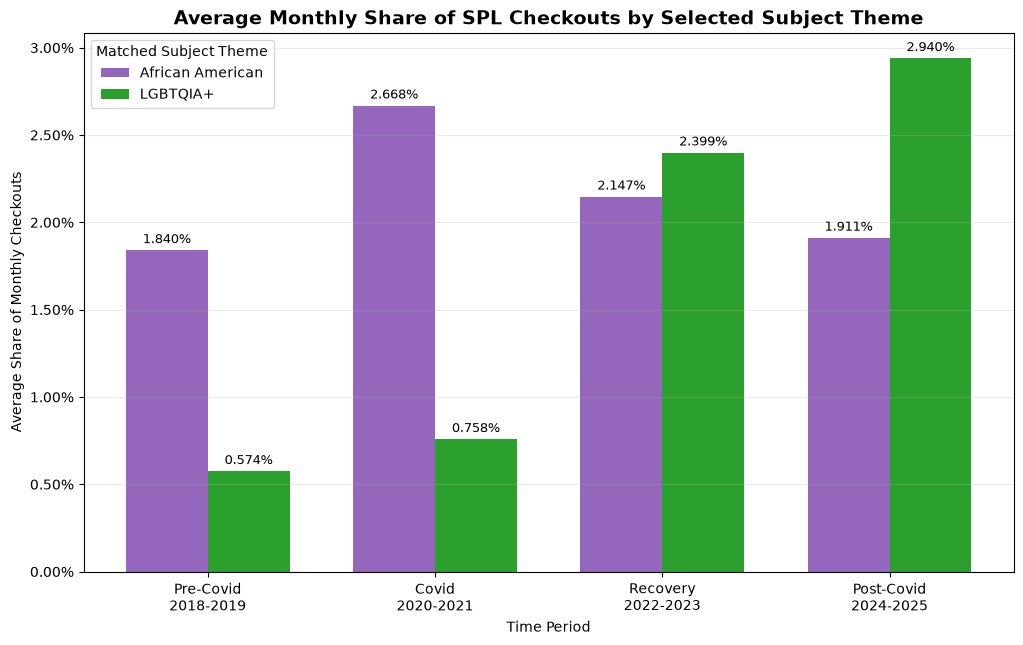

In [6]:
#graph them in order
period_order = [
    "Pre-Covid (2018-2019)",
    "Covid (2020-2021)",
    "Recovery (2022-2023)",
    "Post-Covid (2024-2025)"
]


theme_share_by_period["timeperiod"] = pd.Categorical(
    theme_share_by_period["timeperiod"],
    categories=period_order,
    ordered=True
)


theme_share_by_period = (
    theme_share_by_period
    .sort_values(
        [
            "timeperiod",
            "theme"
        ]
    )
)

theme_share_by_period


# Create the grouped bar chart.
fig, ax = plt.subplots(
    figsize=(12, 7)
)


# Define theme order and colors.
theme_order = [
    "African American",
    "LGBTQIA+"
]

theme_colors = {
    "African American": "tab:purple",
    "LGBTQIA+": "tab:green"
}


# Create one x-axis position per period.
x_positions = list(
    range(len(period_order))
)

bar_width = 0.36


# Plot one set of bars for each theme.
for theme_index, theme in enumerate(theme_order):

    theme_subset = (
        theme_share_by_period[
            theme_share_by_period["theme"] == theme
        ]
        .set_index("timeperiod")
        .reindex(period_order)
    )

    # Position the two theme bars side by side.
    bar_positions = [
        position
        + (theme_index - 0.5) * bar_width
        for position in x_positions
    ]

    bars = ax.bar(
        bar_positions,
        theme_subset["avg_pct_of_monthly_checkouts"],
        width=bar_width,
        color=theme_colors[theme],
        label=theme
    )

    # Add percentages above each bar.
    ax.bar_label(
        bars,
        labels=[
            f"{value:.3f}%"
            for value in
            theme_subset["avg_pct_of_monthly_checkouts"]
        ],
        padding=3,
        fontsize=9
    )


# Format x-axis period labels.
ax.set_xticks(
    x_positions
)

ax.set_xticklabels(
    [
        "Pre-Covid\n2018-2019",
        "Covid\n2020-2021",
        "Recovery\n2022-2023",
        "Post-Covid\n2024-2025"
    ]
)


# Format the y-axis as percentages.
ax.yaxis.set_major_formatter(
    FuncFormatter(
        lambda x, p: f"{x:.2f}%"
    )
)


# Add labels and title.
ax.set_title(
    "Average Monthly Share of SPL Checkouts by Selected Subject Theme",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Time Period")
ax.set_ylabel("Average Share of Monthly Checkouts")

ax.legend(
    title="Matched Subject Theme"
)

ax.grid(
    axis="y",
    alpha=0.25
)


  

- Interest in African American-related materials appears to have experienced a temporary surge during the Covid period before returning closer to pre-pandemic levels.
- The pattern for LGBTQIA+ materials appears to have spiked during the recovery time period, with post-covid levels nearly 5x what they were pre-covid. This could be due to increased availability, increased interest, turmoil/social change, a combination of factors, or something else entirely.

One note: The themes were identified using keyword matching against catalog subject strings. Changes over time may reflect both borrowing behavior and changes in catalog metadata practices. As a result, these findings should be interpreted as directional indicators rather than precise measures of all LGBTQIA+ or African American-related materials in the collection.

### Final Results and Discussion

#### How Did People Borrow?
Prior to Covid, print books represented the largest share of checkouts. During Covid, digital formats increased significantly and became the dominant format, while print books declined sharply (likely due to access restrictions as part of pandemic protocol). Recovery and Post-Covid has not seen a return to pre-pandemic borrowing behavior. This suggests that Covid had an acceleration effect on digital borrowing and that it was not a temporary disruption. One thing to note is that there is a certain group of "evergreen" non-media items, such as headphones and laptops, that are borrowed consistently over time. These utility items are a lesser-known, but clearly consistently utilized, function of the library.

#### What Did People Borrow?
Contrary to borrowing format changes, most subjects remained relatively stable across all four periods. Subject combinations such as:

- Fiction, Literature
- Fiction, Mystery
- Fiction, Mystery, Suspense, Thriller
- Fiction, Romance
- Juvenile Fiction

appeared consistently throughout each time period. This suggests that people borrowed the same type of material as before, even if the way they borrowed those items changed. One note is that there was a gradual disappearance of "Unknown" category items over time, suggesting improvements in cataloging practices during the observed periods.

#### LGBTQIA+ and African American Subject Themes
A deeper analysis of specific topics revealed patterns not immediately visible in the broader subject analysis. 

##### African American Themes
Materials containing African American-related subject headings increased from approximately 1.84% of monthly checkouts before Covid to 2.67% during the Covid period. Following this increase, the share declined during the Recovery and Post-Covid periods, reaching approximately 1.91% in the Post-Covid period. This pattern suggests a temporary increase in borrowing activity associated with African American-related subject headings during the Covid era, followed by a return toward pre-pandemic levels.

##### LGBTQIA+ Themes
Materials containing LGBTQIA+-related subject headings displayed a very different pattern, increasing from approximately 0.57% Pre-Covid to 2.94% in Post-Covid (a 6x increase). Unlike African American-related materials, LGBTQIA+ borrowing activity did not return to pre-pandemic levels. This could be due to growing demand, increased inventory, changing cataloging practices, some combination of those factors, or other unknown reasons.

#### Overall Results
Taken together, the results indicate that borrowers changed how they borrowed more dramatically than what they borrowed. The most significant shifts were observed in borrowing format, particularly the movement toward ebooks and audiobooks. Broad subject preferences remained largely stable over time, although specific themes, particularly LGBTQIA+-related materials, demonstrated sustained growth.

#### Limits and Caveats
- The "Subjects" field contains catalog subject combinations rather than standardized genres. As a result, "Fiction, Romance" and "Fiction, Literature, Romance" were treated as separate values despite them being conceptually the same. This fragmentation likely affects the rankings, and additional data transformation is recommended to group similar values. 
- Cataloging practices appear to have changed over time, especially in the "Unknown" category present in pre-pandemic data. Changes in terminology might also influence observed trends independently of actual behavior.
- LGBTQIA+ and African American analyses relied on keyword matching against catalog values. Some relevant materials may have been classified inconsistently or not captured at all. Results should be interpreted as general catalog activity rather than definitive statements of all materials relating to these communities.
- Checkout activity doesn't measure the full scope of demand, as it's heavily influenced by inventory and availability. In other words, checkouts measure utilization of what's available, not necessarily what patrons want to read. There is no way to measure changes in operating hours, collection development, marketing, access policies, and other factors that might influence checkout activity.

#### Suggested Next Steps
- Other meaningful theme analysis might reveal other trends not immediately apparent (e.g., Mental Health, Cooking/Food, Personal Finance, Career/Employment, Climate, Science/Tech). 
- Analysis of highest-circulating individual titles within LGBTQIA+, African-American, and other themes.
- Other nationwide events (e.g. 2008 Wall Street Crisis), and/or longitudinal analysis of the entire dataset period from 2006-2026.
- Topic tag expansion (splitting Subject metadata strings into individual tags) to create a more flexible and measurable taxonomy.

#### Conclusion
The strongest evidence in the dataset suggests that Covid accelerated a long-term transition toward digital borrowing formats. Seattle Public Library patrons largely continued reading the same broad categories of materials, but increasingly consumed those materials through ebooks and audiobooks. Within the subject analysis, LGBTQIA+-related materials emerged as a notable exception, exhibiting sustained growth as a share of monthly circulation through the Recovery and Post-Covid periods.
